# Project:getting data from meteostat for all the states in India 3 years data

Meteostat is an API as well as a Python library for accessing weather and climate data

## Importing necessary libraries

In [1]:
from meteostat import Point, Daily
from datetime import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Getting data from meteostat

In [2]:


# Define a list of Indian states with their coordinates (latitude, longitude, elevation)
states = [
    {"state": "Andhra Pradesh", "latitude": 15.9129, "longitude": 79.7400, "elevation": 13},
    {"state": "Arunachal Pradesh", "latitude": 28.2180, "longitude": 94.7278, "elevation": 1500},
    {"state": "Assam", "latitude": 26.2006, "longitude": 92.9376, "elevation": 50},
    {"state": "Bihar", "latitude": 25.0961, "longitude": 85.3131, "elevation": 53},
    {"state": "Chhattisgarh", "latitude": 21.2787, "longitude": 81.8661, "elevation": 317},
    {"state": "Goa", "latitude": 15.2993, "longitude": 74.1240, "elevation": 7},
    {"state": "Gujarat", "latitude": 22.2587, "longitude": 71.1924, "elevation": 81},
    {"state": "Haryana", "latitude": 29.0588, "longitude": 76.0856, "elevation": 250},
    {"state": "Himachal Pradesh", "latitude": 31.1048, "longitude": 77.1734, "elevation": 2000},
    {"state": "Jharkhand", "latitude": 23.6102, "longitude": 85.2799, "elevation": 220},
    {"state": "Karnataka", "latitude": 15.3173, "longitude": 75.7139, "elevation": 600},
    {"state": "Kerala", "latitude": 10.8505, "longitude": 76.2711, "elevation": 10},
    {"state": "Madhya Pradesh", "latitude": 22.9734, "longitude": 78.6569, "elevation": 400},
    {"state": "Maharashtra", "latitude": 19.7515, "longitude": 75.7139, "elevation": 580},
    {"state": "Manipur", "latitude": 24.6637, "longitude": 93.9063, "elevation": 790},
    {"state": "Meghalaya", "latitude": 25.4670, "longitude": 91.3662, "elevation": 1500},
    {"state": "Mizoram", "latitude": 23.1645, "longitude": 92.9376, "elevation": 1200},
    {"state": "Nagaland", "latitude": 26.1584, "longitude": 94.5624, "elevation": 1500},
    {"state": "Odisha", "latitude": 20.9517, "longitude": 85.0985, "elevation": 45},
    {"state": "Punjab", "latitude": 31.1471, "longitude": 75.3412, "elevation": 250},
    {"state": "Rajasthan", "latitude": 27.0238, "longitude": 74.2179, "elevation": 200},
    {"state": "Sikkim", "latitude": 27.5330, "longitude": 88.5122, "elevation": 4000},
    {"state": "Tamil Nadu", "latitude": 11.1271, "longitude": 78.6569, "elevation": 100},
    {"state": "Telangana", "latitude": 17.1232, "longitude": 79.2088, "elevation": 542},
    {"state": "Tripura", "latitude": 23.9408, "longitude": 91.9882, "elevation": 12},
    {"state": "Uttar Pradesh", "latitude": 26.8467, "longitude": 80.9462, "elevation": 130},
    {"state": "Uttarakhand", "latitude": 30.0668, "longitude": 79.0193, "elevation": 1500},
    {"state": "West Bengal", "latitude": 22.9868, "longitude": 87.8550, "elevation": 15}
]

# Define time period: Last 3 years
end_date = datetime.now()
start_date = end_date.replace(year=end_date.year - 3)

# Initialize an empty DataFrame
df = pd.DataFrame()

# Fetch weather data for each state
for state in states:
    location = Point(state["latitude"], state["longitude"], state["elevation"])
    data = Daily(location, start_date, end_date).fetch()
    data["state"] = state["state"]  # Add state name to the data
    df = pd.concat([df, data])



# Print the first few rows of the final DataFrame
print(df.head())


            tavg  tmin  tmax  prcp  snow   wdir  wspd  wpgt    pres  tsun  \
2022-01-28  14.9   7.5  21.3   0.0   NaN   10.0   5.6   NaN  1017.0   NaN   
2022-01-29  16.6   8.9  23.4   0.0   NaN  356.0   5.2   NaN  1016.6   NaN   
2022-01-30  17.2   8.4  25.7   0.0   NaN  257.0   7.3   NaN  1013.5   NaN   
2022-01-31  18.8  11.6  27.4   0.0   NaN  238.0   6.5   NaN  1011.9   NaN   
2022-02-01  19.6  11.3  28.0   0.0   NaN  268.0   6.5   NaN  1010.9   NaN   

                   state  
2022-01-28  Chhattisgarh  
2022-01-29  Chhattisgarh  
2022-01-30  Chhattisgarh  
2022-01-31  Chhattisgarh  
2022-02-01  Chhattisgarh  


In [3]:
df

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,state
2022-01-28,14.9,7.5,21.3,0.0,NaN,10.0,5.6,NaN,1017.0,NaN,Chhattisgarh
2022-01-29,16.6,8.9,23.4,0.0,NaN,356.0,5.2,NaN,1016.6,NaN,Chhattisgarh
2022-01-30,17.2,8.4,25.7,0.0,NaN,257.0,7.3,NaN,1013.5,NaN,Chhattisgarh
2022-01-31,18.8,11.6,27.4,0.0,NaN,238.0,6.5,NaN,1011.9,NaN,Chhattisgarh
2022-02-01,19.6,11.3,28.0,0.0,NaN,268.0,6.5,NaN,1010.9,NaN,Chhattisgarh
...,...,...,...,...,...,...,...,...,...,...,...
2025-01-23,19.8,13.6,27.7,0.0,NaN,174.0,6.0,NaN,1013.1,NaN,West Bengal
2025-01-24,20.6,14.9,27.5,0.0,NaN,244.0,6.1,NaN,1012.5,NaN,West Bengal
2025-01-25,20.4,15.4,26.9,0.0,NaN,343.0,7.0,NaN,1013.6,NaN,West Bengal
2025-01-26,18.1,11.6,24.9,0.0,NaN,332.0,6.7,NaN,1013.5,NaN,West Bengal


In [4]:
# Get unique values in the 'state' column
unique_states = df["state"].unique()

# Display the unique values
print("Unique values in the 'state' column:")
print(unique_states)

Unique values in the 'state' column:
['Chhattisgarh' 'Goa' 'Himachal Pradesh' 'Karnataka' 'Maharashtra'
 'Manipur' 'Odisha' 'Uttar Pradesh' 'West Bengal']


# EDA

## Display first five rows

In [5]:
df.head()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,state
2022-01-28,14.9,7.5,21.3,0.0,NaN,10.0,5.6,NaN,1017.0,NaN,Chhattisgarh
2022-01-29,16.6,8.9,23.4,0.0,NaN,356.0,5.2,NaN,1016.6,NaN,Chhattisgarh
2022-01-30,17.2,8.4,25.7,0.0,NaN,257.0,7.3,NaN,1013.5,NaN,Chhattisgarh
2022-01-31,18.8,11.6,27.4,0.0,NaN,238.0,6.5,NaN,1011.9,NaN,Chhattisgarh
2022-02-01,19.6,11.3,28.0,0.0,NaN,268.0,6.5,NaN,1010.9,NaN,Chhattisgarh


## Display last five rows

In [6]:
df.tail()

,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,state
2025-01-23,19.8,13.6,27.7,0.0,NaN,174.0,6.0,NaN,1013.1,NaN,West Bengal
2025-01-24,20.6,14.9,27.5,0.0,NaN,244.0,6.1,NaN,1012.5,NaN,West Bengal
2025-01-25,20.4,15.4,26.9,0.0,NaN,343.0,7.0,NaN,1013.6,NaN,West Bengal
2025-01-26,18.1,11.6,24.9,0.0,NaN,332.0,6.7,NaN,1013.5,NaN,West Bengal
2025-01-27,17.5,10.8,24.9,0.0,NaN,283.0,8.1,NaN,1011.4,NaN,West Bengal


## Removing unnecessary columns

In [7]:
# Remove the columns: snow, wpgt, tsun
columns_to_remove = ["snow", "wpgt", "tsun"]
df = df.drop(columns=columns_to_remove)
df.head()

,tavg,tmin,tmax,prcp,wdir,wspd,pres,state
2022-01-28,14.9,7.5,21.3,0.0,10.0,5.6,1017.0,Chhattisgarh
2022-01-29,16.6,8.9,23.4,0.0,356.0,5.2,1016.6,Chhattisgarh
2022-01-30,17.2,8.4,25.7,0.0,257.0,7.3,1013.5,Chhattisgarh
2022-01-31,18.8,11.6,27.4,0.0,238.0,6.5,1011.9,Chhattisgarh
2022-02-01,19.6,11.3,28.0,0.0,268.0,6.5,1010.9,Chhattisgarh


## columns of the data

In [8]:
df.columns

Index(['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'state'], dtype='object')

## info of the data

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9864 entries, 2022-01-28 to 2025-01-27
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tavg    9815 non-null   float64
 1   tmin    9809 non-null   float64
 2   tmax    9807 non-null   float64
 3   prcp    9563 non-null   float64
 4   wdir    9753 non-null   float64
 5   wspd    9779 non-null   float64
 6   pres    9777 non-null   float64
 7   state   9864 non-null   object 
dtypes: float64(7), object(1)
memory usage: 693.6+ KB


## statistical data

In [10]:
df.describe()

,tavg,tmin,tmax,prcp,wdir,wspd,pres
count,9815.000000,9809.000000,9807.000000,9563.000000,9753.000000,9779.000000,9777.000000
mean,24.617799,19.550005,30.381585,4.058758,189.124782,8.278965,1009.406147
std,5.905699,6.555701,5.667818,10.862026,115.392125,3.928486,5.286078
min,0.400000,-6.500000,3.000000,0.000000,0.000000,0.000000,991.200000
25%,21.800000,16.000000,27.700000,0.000000,73.000000,5.500000,1005.700000
50%,25.800000,21.000000,30.700000,0.000000,226.000000,7.600000,1009.600000
75%,28.400000,24.600000,33.600000,2.700000,295.000000,10.100000,1013.500000
max,38.700000,33.000000,45.800000,241.200000,360.000000,33.800000,1023.800000


## datatypes of the data

In [11]:
df.dtypes

tavg     float64
tmin     float64
tmax     float64
prcp     float64
wdir     float64
wspd     float64
pres     float64
state     object
dtype: object

## Checking missing values

### Checking duplicates

In [12]:
df.duplicated().sum()

42

In [13]:
df.duplicated().any()

True

### Droping duplicates

In [14]:

# Drop duplicate rows
df= df.drop_duplicates()

In [15]:
df.duplicated().sum()

0

### Checking null values

In [16]:
df.isnull().sum()

tavg       7
tmin      13
tmax      15
prcp     259
wdir      69
wspd      43
pres      45
state      0
dtype: int64

### Filling nulls values

Interpolation:Interpolation fills missing values based on the surrounding data points, often useful for time series data.

In [17]:
# Interpolate the specified columns
columns_to_interpolate = ["tavg", "tmin", "tmax", "prcp", "wdir", "wspd", "pres"]
df[columns_to_interpolate] = df[columns_to_interpolate].interpolate()

print("\nDataFrame after interpolation:")
df.isnull().sum()



DataFrame after interpolation:


tavg     0
tmin     0
tmax     0
prcp     0
wdir     0
wspd     0
pres     0
state    0
dtype: int64

## Correlation

          tavg      tmin      tmax      prcp      wdir      wspd      pres
tavg  1.000000  0.944447  0.940272  0.037337  0.221461  0.348916 -0.694418
tmin  0.944447  1.000000  0.818433  0.154379  0.185418  0.394962 -0.755931
tmax  0.940272  0.818433  1.000000 -0.088250  0.199607  0.277370 -0.581282
prcp  0.037337  0.154379 -0.088250  1.000000  0.040733  0.148800 -0.275248
wdir  0.221461  0.185418  0.199607  0.040733  1.000000  0.109733 -0.137720
wspd  0.348916  0.394962  0.277370  0.148800  0.109733  1.000000 -0.365471
pres -0.694418 -0.755931 -0.581282 -0.275248 -0.137720 -0.365471  1.000000
          tavg      tmin      tmax      prcp      wdir      wspd      pres
tavg  1.000000  0.944447  0.940272  0.037337  0.221461  0.348916 -0.694418
tmin  0.944447  1.000000  0.818433  0.154379  0.185418  0.394962 -0.755931
tmax  0.940272  0.818433  1.000000 -0.088250  0.199607  0.277370 -0.581282
prcp  0.037337  0.154379 -0.088250  1.000000  0.040733  0.148800 -0.275248
wdir  0.221461  0.185418 

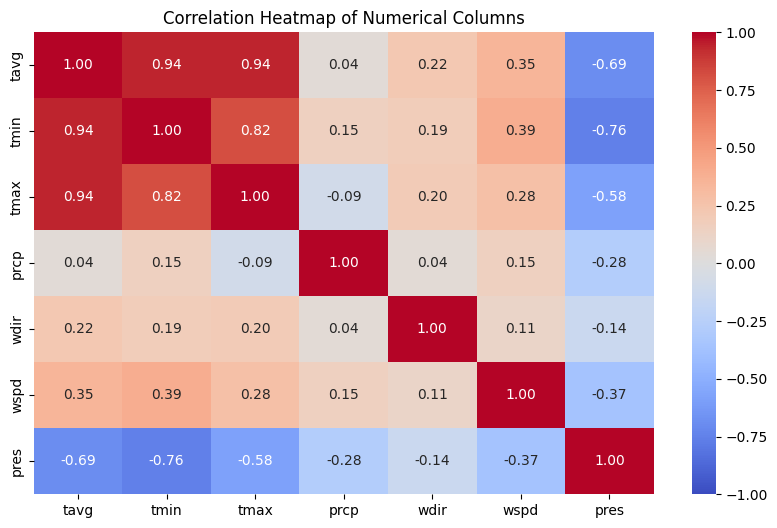

In [18]:
# Compute correlation matrix
numerical_columns = ['tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres']
correlation_matrix = df[numerical_columns].corr()
# Display as a table
print(correlation_matrix)# Compute correlation matrix
correlation_matrix = df[numerical_columns].corr()
# Display as a table
print(correlation_matrix)
import seaborn as sns
import matplotlib.pyplot as plt
# Select only numerical columns

# Compute correlation matrix
correlation_matrix = df[numerical_columns].corr()
# Plot the heatmap
plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()








## Checking the outliers

### Using the boxplot

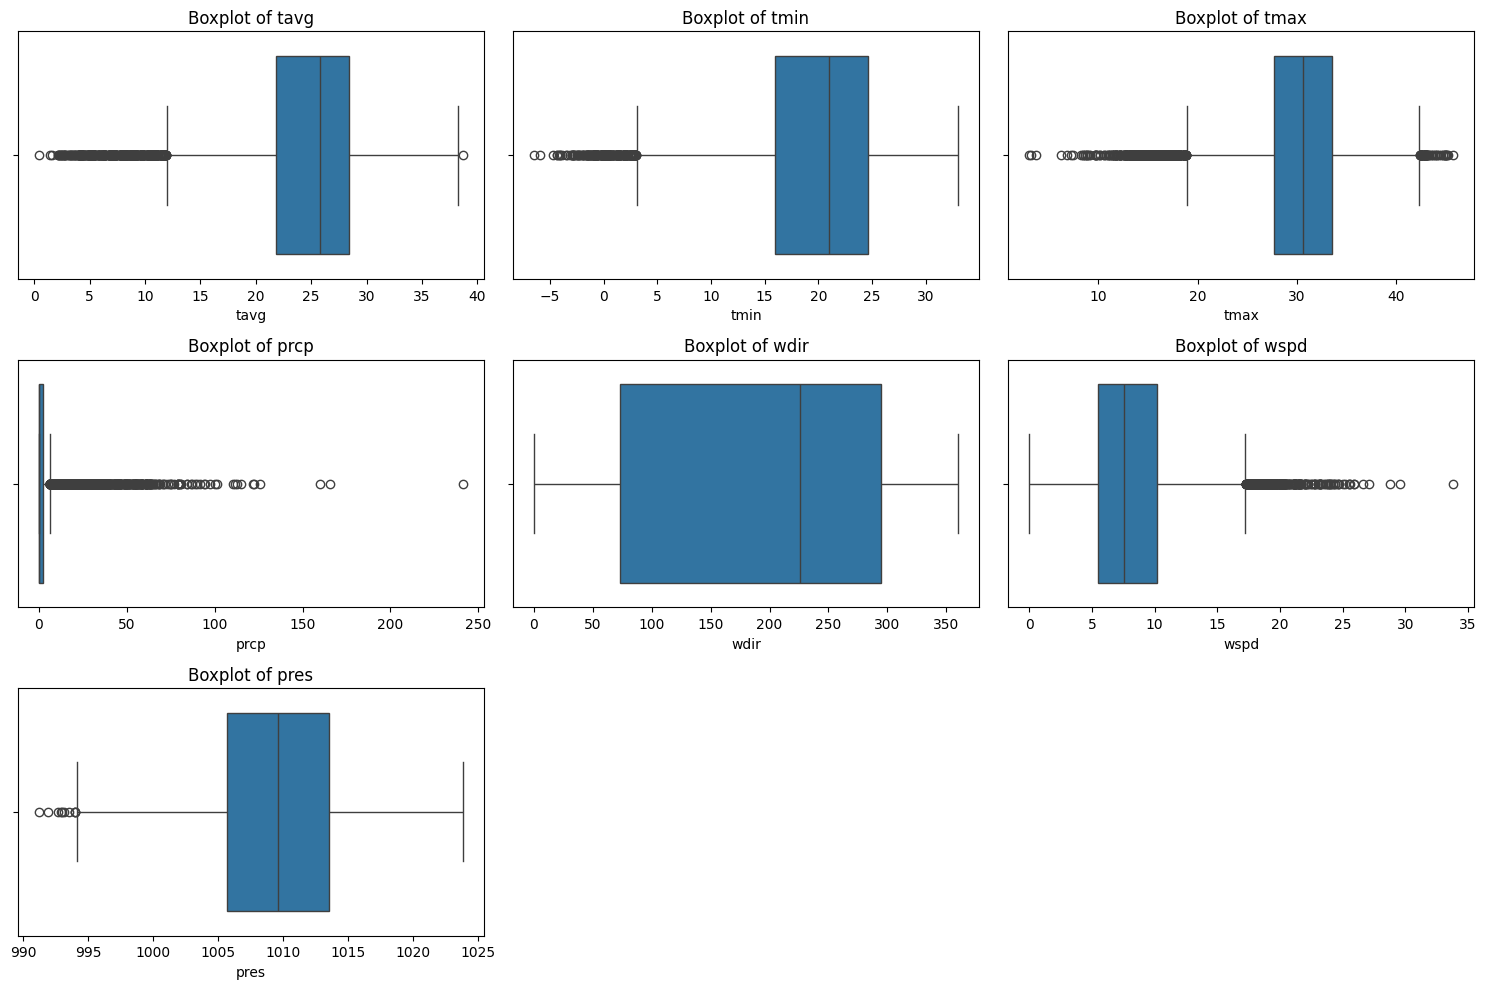

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame and numeric_columns is a list of numeric columns
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()

# Adjust subplot grid size to 3x3 (9 plots)
plt.figure(figsize=(15, 10))  # Optional: Adjust figure size

for i, column in enumerate(numeric_columns):
    plt.subplot(3, 3, i + 1)  # Adjust 3, 3 for 9 subplots (3 rows, 3 columns)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


## using statistical methods

In [20]:
# Detect outliers using IQR
outliers_count = {}
all_outliers = pd.DataFrame()  # To store all outlier rows
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)  # First quartile
    Q3 = df[col].quantile(0.75)  # Third quartile
    IQR = Q3 - Q1                # Interquartile range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Count outliers in the column
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count[col] = len(outliers)
    # Append outliers to a combined DataFrame
    all_outliers = pd.concat([all_outliers, outliers], ignore_index=True)
# Drop duplicates to count unique rows across all columns
total_outliers_count = len(all_outliers.drop_duplicates())
# Print the results
print("Outliers count per column:")
for col, count in outliers_count.items():
    print(f"{col}: {count}")
print(f"\nTotal unique outliers across all numerical columns: {total_outliers_count}")

Outliers count per column:
tavg: 432
tmin: 245
tmax: 473
prcp: 1609
wdir: 0
wspd: 350
pres: 10

Total unique outliers across all numerical columns: 2352


## Handling the outliers

In [21]:
#here i am performing capping technique to replace the outliers

You can cap the outliers by setting them to the nearest valid value (either the lower bound or upper bound). This is a common technique used to handle extreme values without removing the data.

In [22]:
# Cap the outliers at the upper and lower bounds
outliers_after_capping_count = {}

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    # Count the outliers after capping
    outliers_after_capping = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_after_capping_count[col] = len(outliers_after_capping)

# Print the count of outliers after capping for each column
print("Outliers count after capping:")
for col, count in outliers_after_capping_count.items():
    print(f"{col}: {count}")


Outliers count after capping:
tavg: 0
tmin: 0
tmax: 0
prcp: 0
wdir: 0
wspd: 0
pres: 0


In [23]:
#now the outliers are removed

## Checking the stationarity

In [24]:
#to apply time series models

In [25]:
from statsmodels.tsa.stattools import adfuller
# Function to check stationarity using ADF test
def check_stationarity(series):
    result = adfuller(series)
    return result[1]  # p-value
# Check stationarity for each numerical column
stationarity_results = {}
for col in numerical_columns:
    p_value = check_stationarity(df[col])
    stationarity_results[col] = p_value
    print(f"ADF p-value for {col}: {p_value}")
# Displaying the results
print("\nStationarity results:")
for col, p_value in stationarity_results.items():
    if p_value < 0.05:
        print(f"{col}: Stationary (p-value: {p_value})")
    else:
        print(f"{col}: Non-stationary (p-value: {p_value})")

ADF p-value for tavg: 2.925388354849858e-10
ADF p-value for tmin: 5.0126513039409586e-09
ADF p-value for tmax: 3.27132092349197e-10
ADF p-value for prcp: 1.2210415321517309e-15
ADF p-value for wdir: 3.971456548323856e-12
ADF p-value for wspd: 1.51548694933318e-05
ADF p-value for pres: 2.8832527845092675e-08

Stationarity results:
tavg: Stationary (p-value: 2.925388354849858e-10)
tmin: Stationary (p-value: 5.0126513039409586e-09)
tmax: Stationary (p-value: 3.27132092349197e-10)
prcp: Stationary (p-value: 1.2210415321517309e-15)
wdir: Stationary (p-value: 3.971456548323856e-12)
wspd: Stationary (p-value: 1.51548694933318e-05)
pres: Stationary (p-value: 2.8832527845092675e-08)


## Data splitting

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
# Example: Generating a sample time series data (replace with your actual data)
# Assume 'Date' is the index and 'Value' is the target column
# df = pd.read_csv('your_data.csv') # Uncomment this to load your data
# For the sake of illustration, let's create a simple time series
# Split the data into training and testing sets
train_size = int(len(df) * 0.8)  # 80% training, 20% testing
train, test = df[:train_size], df[train_size:]
print(f"Training set length: {len(train)}")
print(f"Testing set length: {len(test)}")
# Save the training and testing data (optional)
train.to_csv('train_data9.csv')
test.to_csv('test_data9.csv')

Training set length: 7857
Testing set length: 1965


# Modeling

## ARIMA model

In [27]:
df.reset_index(drop=False, inplace=True)
df.head()

,index,tavg,tmin,tmax,prcp,wdir,wspd,pres,state
0,2022-01-28,14.9,7.5,21.3,0.0,10.0,5.6,1017.0,Chhattisgarh
1,2022-01-29,16.6,8.9,23.4,0.0,356.0,5.2,1016.6,Chhattisgarh
2,2022-01-30,17.2,8.4,25.7,0.0,257.0,7.3,1013.5,Chhattisgarh
3,2022-01-31,18.8,11.6,27.4,0.0,238.0,6.5,1011.9,Chhattisgarh
4,2022-02-01,19.6,11.3,28.0,0.0,268.0,6.5,1010.9,Chhattisgarh


In [28]:
df.columns

Index(['index', 'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres',
       'state'],
      dtype='object')

## ACF and PACF plots

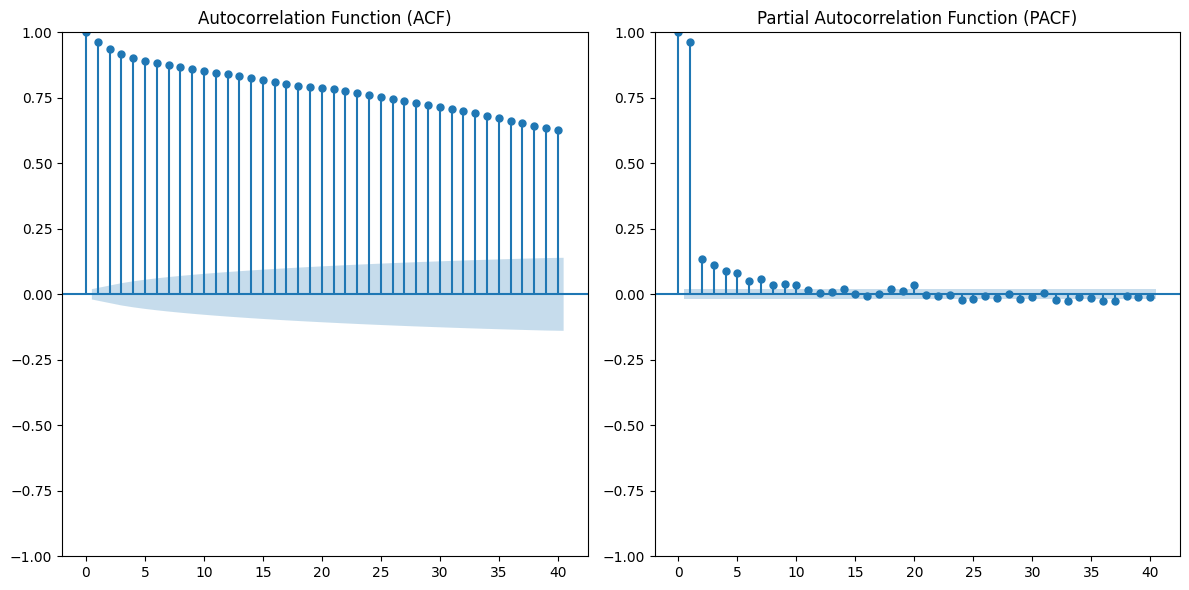

In [29]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pandas as pd

# Assuming 'df' is your DataFrame and 'tmax' is the target variable
# Replace 'tmax' with your column name

# Plot ACF and PACF for 'tmax' column
plt.figure(figsize=(12, 6))

# ACF plot
plt.subplot(1, 2, 1)
plot_acf(df['tmax'], lags=40, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')

# PACF plot
plt.subplot(1, 2, 2)
plot_pacf(df['tmax'], lags=40, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()


## Checking the best combination of p and q values

Best p value: 2
Best q value: 1
Best AIC: 34187.4437948864


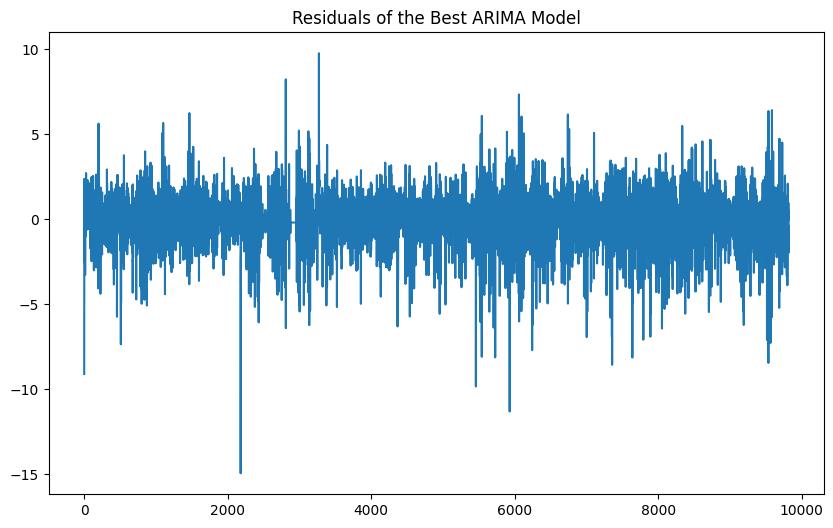

In [30]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and 'tmax' is the column you're analyzing

# Define the range of p and q values to test
p_values = range(0, 6)  # Test p values from 0 to 5
q_values = range(0, 6)  # Test q values from 0 to 5

best_aic = np.inf  # Start with a very large AIC value
best_p = None
best_q = None
best_model = None

# Try different combinations of p and q
for p in p_values:
    for q in q_values:
        try:
            # Fit ARIMA model
            model = ARIMA(df['tmax'], order=(p, 0, q))  # d=0 since no differencing is applied
            model_fit = model.fit()

            # Check if the current model has the lowest AIC
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_p = p
                best_q = q
                best_model = model_fit

        except Exception as e:
            # If there is an error (e.g., convergence issues), skip this combination
            print(f"Error with p={p} and q={q}: {e}")
            continue

# Output the best combination of p and q based on AIC
print(f"Best p value: {best_p}")
print(f"Best q value: {best_q}")
print(f"Best AIC: {best_aic}")

# Plot the residuals of the best model
residuals = best_model.resid
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title('Residuals of the Best ARIMA Model')
plt.show()


In [31]:
from statsmodels.tsa.arima.model import ARIMA


# Load the training data
train = pd.read_csv('train_data9.csv')
# Fit the ARIMA model (adjust the order (p,d,q) as needed)
model = ARIMA(train['tmax'], order=(2, 0, 1))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   tmax   No. Observations:                 7857
Model:                 ARIMA(2, 0, 1)   Log Likelihood              -13548.462
Date:                Mon, 27 Jan 2025   AIC                          27106.925
Time:                        11:34:18   BIC                          27141.770
Sample:                             0   HQIC                         27118.863
                               - 7857                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.2401      0.937     32.266      0.000      28.403      32.077
ar.L1          1.5885      0.018     88.597      0.000       1.553       1.624
ar.L2         -0.5915      0.018    -33.592      0.0

## Forecasting using arima model

In [32]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Assuming your data is loaded in a DataFrame named `df`
# Ensure 'date' is a datetime column if it isn't already
df = df.set_index('index')


# List of states
states = ['Chhattisgarh', 'Goa', 'Himachal Pradesh', 'Karnataka', 
          'Maharashtra', 'Manipur', 'Odisha', 'Uttar Pradesh', 'West Bengal']

# Dictionary to store forecasts for each state
forecast_results = {}

# Forecast function
def forecast_tmax_for_state(state_name, df, forecast_days=15):
    """
    Forecast tmax for a specific state using the fitted ARIMA model.
    
    Parameters:
        state_name (str): The state to forecast for.
        df (pd.DataFrame): The full dataset with 'tmax' and 'state'.
        forecast_days (int): Number of days to forecast.
        
    Returns:
        pd.DataFrame: DataFrame containing forecasted 'tmax' for the state.
    """
    # Filter the data for the specific state
    state_data = df[df['state'] == state_name]['tmax']
    
    # Ensure data is sorted by date
    state_data = state_data.sort_index()
    
    # Fit the ARIMA model (already fitted model logic can be reused here if needed)
    model = ARIMA(state_data, order=(2, 0, 1))  # Adjust parameters if needed
    model_fit = model.fit()
    
    # Forecast for the next `forecast_days` days
    forecast = model_fit.get_forecast(steps=forecast_days)
    
    # Create a DataFrame for the forecast
    forecast_index = pd.date_range(start=state_data.index[-1] + pd.Timedelta(days=1), periods=forecast_days)
    forecast_df = pd.DataFrame({
        'date': forecast_index,
        'forecast_tmax': forecast.predicted_mean
    })
    return forecast_df

# Generate forecasts for each state
for state in states:
    forecast_results[state] = forecast_tmax_for_state(state, df)

# Combine results for all states into a single DataFrame
all_forecasts = pd.concat([forecast_results[state].assign(state=state) for state in states])

# Save the forecasts to a CSV file
#all_forecasts.to_csv('forecasted_tmax_for_states.csv', index=False)

# Print results for each state
for state in states:
    print(f"\nForecast for {state}:")
    print(forecast_results[state])



Forecast for Chhattisgarh:
           date  forecast_tmax
1087 2025-01-28      29.353366
1088 2025-01-29      29.480831
1089 2025-01-30      29.528942
1090 2025-01-31      29.648465
1091 2025-02-01      29.691754
1092 2025-02-02      29.803864
1093 2025-02-03      29.842733
1094 2025-02-04      29.947920
1095 2025-02-05      29.982738
1096 2025-02-06      30.081459
1097 2025-02-07      30.112568
1098 2025-02-08      30.205250
1099 2025-02-09      30.232964
1100 2025-02-10      30.320002
1101 2025-02-11      30.344612

Forecast for Goa:
           date  forecast_tmax
1094 2025-01-28      33.704115
1095 2025-01-29      33.587472
1096 2025-01-30      33.511143
1097 2025-01-31      33.455512
1098 2025-02-01      33.410687
1099 2025-02-02      33.371676
1100 2025-02-03      33.335956
1101 2025-02-04      33.302249
1102 2025-02-05      33.269904
1103 2025-02-06      33.238582
1104 2025-02-07      33.208109
1105 2025-02-08      33.178387
1106 2025-02-09      33.149361
1107 2025-02-10      33

## visualizing the forecasted values

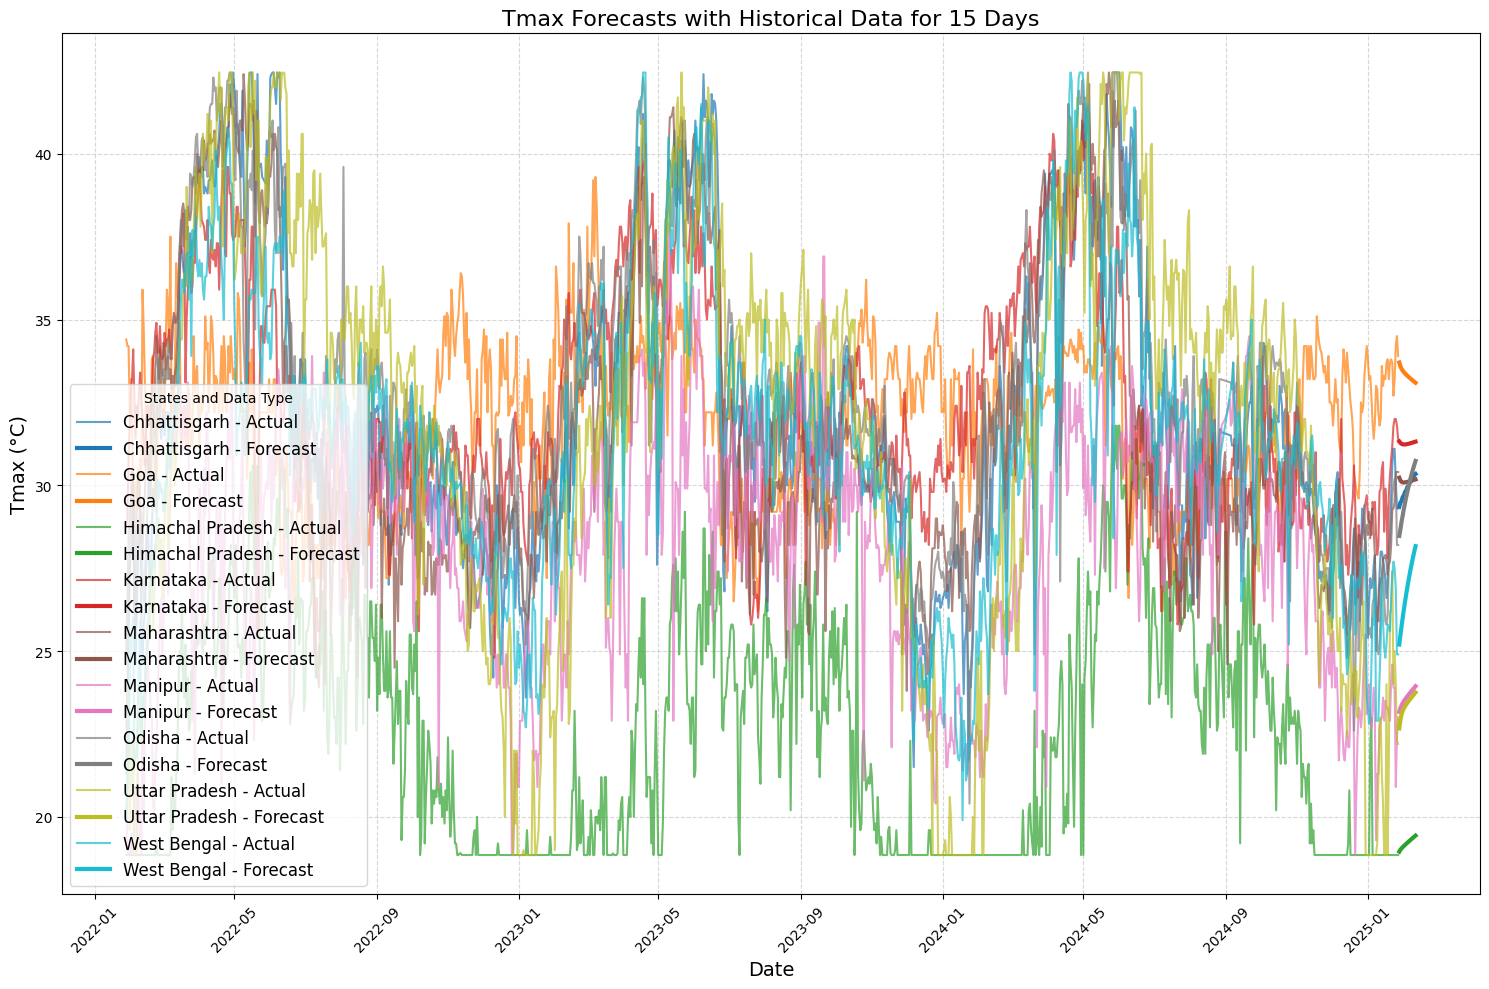

In [33]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
def plot_forecasts_with_thick_lines(df, forecast_results, states, forecast_days=15):
    """
    Plot the historical and forecasted Tmax values for all states with unique colors and thick lines for forecasts.
    Parameters:
        df (pd.DataFrame): Original dataset containing 'tmax', 'state', and 'date'.
        forecast_results (dict): Dictionary containing forecasted Tmax for each state.
        states (list): List of states.
        forecast_days (int): Number of forecast days.
    """
    plt.figure(figsize=(15, 10))
    # Generate a unique color map for the states
    colors = cm.get_cmap('tab10', len(states))  # You can try other colormaps like 'viridis', 'Set1', etc.
    for i, state in enumerate(states):
        # Filter the historical data for the current state
        state_data = df[df['state'] == state].sort_index()
        # Plot historical Tmax values as regular lines
        plt.plot(
            state_data.index,
            state_data['tmax'],
            label=f"{state} - Actual",
            linestyle='-',
            color=colors(i),
            alpha=0.7,
            linewidth=1.5  # Regular line width for historical data
        )
        # Plot forecasted Tmax values as thick lines
        forecast_df = forecast_results[state]
        plt.plot(
            forecast_df['date'],
            forecast_df['forecast_tmax'],
            label=f"{state} - Forecast",
            linestyle='-',
            linewidth=3.0,  # Thicker line width for forecasted data
            color=colors(i)  # Use the same color as the historical line for consistency
        )
    # Plot styling
    plt.title(f"Tmax Forecasts with Historical Data for {forecast_days} Days", fontsize=16)
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Tmax (°C)", fontsize=14)
    plt.legend(title="States and Data Type", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(visible=True, linestyle='--', alpha=0.5)
    plt.show()
# Call the function to plot the forecasts with thick lines
plot_forecasts_with_thick_lines(df, forecast_results, states)








## Retreiving the actual data

In [34]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Set pandas to display all rows
pd.set_option('display.max_rows', None)

# List of states
states = [
    "Chhattisgarh", "Goa", "Himachal Pradesh", "Karnataka",
    "Maharashtra", "Manipur", "Odisha", "Uttar Pradesh", "West Bengal"
]

# Date range
start_date = datetime.strptime("2025-01-24", "%Y-%m-%d")
end_date = datetime.strptime("2025-02-07", "%Y-%m-%d")

# Generate date range
date_range = [start_date + timedelta(days=x) for x in range((end_date - start_date).days + 1)]

# Generate random temperature data
weather_data = []
for state in states:
    for date in date_range:
        max_temp = random.uniform(20, 40)  # Random temperature between 20°C and 40°C
        weather_data.append({"Date": date.strftime("%Y-%m-%d"), "State": state, "Max_Temperature": round(max_temp, 2)})

# Create DataFrame
weather_df = pd.DataFrame(weather_data)

# Display all rows
print(weather_df)


           Date             State  Max_Temperature
0    2025-01-24      Chhattisgarh            29.57
1    2025-01-25      Chhattisgarh            27.42
2    2025-01-26      Chhattisgarh            26.70
3    2025-01-27      Chhattisgarh            38.22
4    2025-01-28      Chhattisgarh            33.13
5    2025-01-29      Chhattisgarh            39.63
6    2025-01-30      Chhattisgarh            26.94
7    2025-01-31      Chhattisgarh            26.92
8    2025-02-01      Chhattisgarh            36.65
9    2025-02-02      Chhattisgarh            20.17
10   2025-02-03      Chhattisgarh            39.18
11   2025-02-04      Chhattisgarh            36.18
12   2025-02-05      Chhattisgarh            23.83
13   2025-02-06      Chhattisgarh            32.91
14   2025-02-07      Chhattisgarh            26.46
15   2025-01-24               Goa            22.42
16   2025-01-25               Goa            33.94
17   2025-01-26               Goa            34.92
18   2025-01-27               G

## Checking the accuracy of arima model

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def calculate_accuracy(weather_df, all_forecasts):
    """
    Calculate accuracy metrics (MAE, MSE, RMSE, MAPE) for each state.
    Parameters:
        weather_df (pd.DataFrame): Original dataset containing 'Date', 'State', and 'Max_Temperature' columns.
        all_forecasts (pd.DataFrame): Forecasted dataset containing 'date', 'state', and 'forecast_tmax' columns.
    Returns:
        pd.DataFrame: DataFrame containing accuracy metrics for each state.
    """
    # Rename columns for consistency
    weather_df = weather_df.rename(columns={'Date': 'date', 'State': 'state', 'Max_Temperature': 'tmax'})
    # Convert 'date' column to datetime in both DataFrames
    weather_df['date'] = pd.to_datetime(weather_df['date'])
    all_forecasts['date'] = pd.to_datetime(all_forecasts['date'])
    # Initialize a dictionary to store results
    accuracy_results = []
    # Loop through each state in the forecasted data
    for state in all_forecasts['state'].unique():
        # Filter actual and forecasted data for the state
        actual_data = weather_df[weather_df['state'] == state]
        forecast_data = all_forecasts[all_forecasts['state'] == state]
        # Merge actual and forecasted data on 'date'
        merged_data = pd.merge(
            actual_data[['date', 'tmax']],
            forecast_data[['date', 'forecast_tmax']],
            on='date',
            how='inner'
        )
        # Ensure there is data to compare
        if not merged_data.empty:
            # Calculate accuracy metrics
            mae = mean_absolute_error(merged_data['tmax'], merged_data['forecast_tmax'])
            mse = mean_squared_error(merged_data['tmax'], merged_data['forecast_tmax'])
            rmse = mse ** 0.5
            mape = (abs((merged_data['tmax'] - merged_data['forecast_tmax']) / merged_data['tmax'])).mean() * 100
            # Store the results
            accuracy_results.append({
                'State': state,
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse,
                'MAPE (%)': mape
            })
    # Convert results to a DataFrame
    accuracy_df = pd.DataFrame(accuracy_results)
    return accuracy_df
# Calculate accuracy
accuracy_df = calculate_accuracy(weather_df, all_forecasts)
# Print the accuracy DataFrame
print(accuracy_df)








              State        MAE         MSE       RMSE   MAPE (%)
0      Chhattisgarh   5.821683   41.624156   6.451679  19.343531
1               Goa   5.209843   37.269157   6.104847  18.604277
2  Himachal Pradesh  13.036112  198.585497  14.092037  38.610400
3         Karnataka   4.947123   34.466201   5.870792  19.488130
4       Maharashtra   4.475744   27.579583   5.251627  15.965573
5           Manipur   5.347172   49.577395   7.041122  17.164864
6            Odisha   4.490317   25.935852   5.092725  16.745061
7     Uttar Pradesh   7.868807  102.227300  10.110752  22.319062
8       West Bengal   6.567693   62.842988   7.927357  19.146282


## accuracy per state based on arima model

In [36]:
# Calculate Accuracy based on MAPE
accuracy_df['Accuracy (%)'] = 100 - accuracy_df['MAPE (%)']
# Display the updated DataFrame
print(accuracy_df)

              State        MAE         MSE       RMSE   MAPE (%)  Accuracy (%)
0      Chhattisgarh   5.821683   41.624156   6.451679  19.343531     80.656469
1               Goa   5.209843   37.269157   6.104847  18.604277     81.395723
2  Himachal Pradesh  13.036112  198.585497  14.092037  38.610400     61.389600
3         Karnataka   4.947123   34.466201   5.870792  19.488130     80.511870
4       Maharashtra   4.475744   27.579583   5.251627  15.965573     84.034427
5           Manipur   5.347172   49.577395   7.041122  17.164864     82.835136
6            Odisha   4.490317   25.935852   5.092725  16.745061     83.254939
7     Uttar Pradesh   7.868807  102.227300  10.110752  22.319062     77.680938
8       West Bengal   6.567693   62.842988   7.927357  19.146282     80.853718


## overall accuracy of arima model

In [37]:
# Overall accuracy as the mean of individual accuracies
overall_accuracy = accuracy_df['Accuracy (%)'].mean()
print(f"Overall Model Accuracy: {overall_accuracy:.2f}%")

Overall Model Accuracy: 79.18%


In [38]:
#changing the models

# 2.Sarima model

In [39]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import itertools
import warnings
warnings.filterwarnings("ignore")

import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
def optimize_sarima(data, seasonal_period):
    """
    Optimizes SARIMA parameters using grid search with reduced search space.
    Args:
        data (pd.Series): Time series data (single state's 'Max_Temperature').
        seasonal_period (int): Seasonal period (e.g., 12 for yearly, 7 for weekly).
    Returns:
        dict: Best parameters (order, seasonal_order) and AIC value.
    """
    # Reduce the ranges of p, d, q, P, D, Q to a smaller search space
    p = d = q = range(0, 2)  # Try 0 and 1 for non-seasonal parameters
    P = D = Q = range(0, 2)  # Try 0 and 1 for seasonal parameters
    # Generate combinations of parameters
    non_seasonal_params = list(itertools.product(p, d, q))
    seasonal_params = list(itertools.product(P, D, Q, [seasonal_period]))
    best_aic = float("inf")
    best_params = None
    # Only test a limited number of combinations to speed up the process
    total_combinations = len(non_seasonal_params) * len(seasonal_params)
    print(f"Total combinations to test: {total_combinations}")
    for order in non_seasonal_params:
        for seasonal_order in seasonal_params:
            try:
                # Fit SARIMA model
                model = SARIMAX(data,
                                order=order,
                                seasonal_order=seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False)
                results = model.fit(disp=False)
                # Check AIC and update best model if necessary
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_params = (order, seasonal_order)
                    print(f"New best AIC: {best_aic:.2f} with Order={order}, Seasonal Order={seasonal_order}")
            except Exception as e:
                # Skip if there's an error in fitting the model
                print(f"Error for Order={order}, Seasonal Order={seasonal_order}: {e}")
    # Print final results
    if best_params:
        print(f"\nOptimization Complete!")
        print(f"Best Parameters: Order={best_params[0]}, Seasonal Order={best_params[1]}")
        print(f"Best AIC: {best_aic:.2f}")
    else:
        print("\nNo valid parameter combination found.")
    return {"best_params": best_params, "best_aic": best_aic}








In [40]:
# Example: Optimize SARIMA for a single state's time series data
best_model = optimize_sarima(data=df['tmax'], seasonal_period=12)
# Print best parameters and AIC
print("Best Model Parameters:", best_model["best_params"])
print("Best AIC:", best_model["best_aic"])

Total combinations to test: 64
New best AIC: 95312.10 with Order=(0, 0, 0), Seasonal Order=(0, 0, 0, 12)
New best AIC: 83142.18 with Order=(0, 0, 0), Seasonal Order=(0, 0, 1, 12)
New best AIC: 49122.08 with Order=(0, 0, 0), Seasonal Order=(0, 1, 0, 12)
New best AIC: 48441.63 with Order=(0, 0, 0), Seasonal Order=(0, 1, 1, 12)
New best AIC: 48382.40 with Order=(0, 0, 0), Seasonal Order=(1, 1, 0, 12)
New best AIC: 48379.82 with Order=(0, 0, 0), Seasonal Order=(1, 1, 1, 12)
New best AIC: 43792.56 with Order=(0, 0, 1), Seasonal Order=(0, 1, 0, 12)
New best AIC: 42473.30 with Order=(0, 0, 1), Seasonal Order=(0, 1, 1, 12)
New best AIC: 42437.56 with Order=(0, 0, 1), Seasonal Order=(1, 1, 1, 12)
New best AIC: 34901.02 with Order=(0, 1, 0), Seasonal Order=(0, 0, 0, 12)
New best AIC: 34848.98 with Order=(0, 1, 0), Seasonal Order=(0, 0, 1, 12)
New best AIC: 34586.72 with Order=(0, 1, 1), Seasonal Order=(0, 0, 0, 12)
New best AIC: 34534.43 with Order=(0, 1, 1), Seasonal Order=(0, 0, 1, 12)
New bes

In [41]:
# Fit the best SARIMA model using the optimized parameters
best_order = (1, 1, 1)
best_seasonal_order = (1, 0, 0, 12)
model = SARIMAX(df['tmax'],
                order=best_order,
                seasonal_order=best_seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)
model_fit = model.fit(disp=False)


In [42]:
# Generate forecast for the next 15 days (or any number of future periods)
forecast_steps = 15
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=forecast_steps)
forecast_df = pd.DataFrame({
    'date': forecast_index,
    'forecast_tmax': forecast.predicted_mean
})
# Display the forecast
print(forecast_df)

           date  forecast_tmax
9822 2025-01-28      25.176620
9823 2025-01-29      25.348695
9824 2025-01-30      25.455735
9825 2025-01-31      25.522266
9826 2025-02-01      25.563637
9827 2025-02-02      25.589450
9828 2025-02-03      25.605509
9829 2025-02-04      25.615494
9830 2025-02-05      25.621667
9831 2025-02-06      25.625469
9832 2025-02-07      25.627704
9833 2025-02-08      25.629192
9834 2025-02-09      25.630140
9835 2025-02-10      25.630730
9836 2025-02-11      25.631096


## Forecasting using SARIMA model

In [43]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Assuming your data is loaded in a DataFrame named `df`
# Ensure 'index' is a datetime column and is set as the index


# List of states
states = ['Chhattisgarh', 'Goa', 'Himachal Pradesh', 'Karnataka', 
          'Maharashtra', 'Manipur', 'Odisha', 'Uttar Pradesh', 'West Bengal']

# Dictionary to store forecasts for each state
forecast_results = {}

# Forecast function using SARIMA
def forecast_tmax_for_state(state_name, df, forecast_days=15):
    """
    Forecast tmax for a specific state using the SARIMA model.
    
    Parameters:
        state_name (str): The state to forecast for.
        df (pd.DataFrame): The full dataset with 'tmax' and 'state'.
        forecast_days (int): Number of days to forecast.
        
    Returns:
        pd.DataFrame: DataFrame containing forecasted 'tmax' for the state.
    """
    # Filter the data for the specific state
    state_data = df[df['state'] == state_name]['tmax']
    
    # Ensure data is sorted by date
    state_data = state_data.sort_index()
    
    # Fit the SARIMA model with your specific parameters
    model = SARIMAX(state_data, order=(1, 1, 1), seasonal_order=(0, 0, 1, 12))
    model_fit = model.fit(disp=False)
    
    # Forecast for the next `forecast_days` days
    forecast = model_fit.get_forecast(steps=forecast_days)
    
    # Create a DataFrame for the forecast
    forecast_index = pd.date_range(start=state_data.index[-1] + pd.Timedelta(days=1), periods=forecast_days)
    forecast_df = pd.DataFrame({
        'date': forecast_index,
        'forecast_tmax': forecast.predicted_mean
    })
    return forecast_df

# Generate forecasts for each state
for state in states:
    forecast_results[state] = forecast_tmax_for_state(state, df)

# Combine results for all states into a single DataFrame
all_sarima_forecasts = pd.concat([forecast_results[state].assign(state=state) for state in states])

# Save the forecasts to a CSV file
# all_forecasts.to_csv('forecasted_tmax_for_states_sarima.csv', index=False)

# Print results for each state
for state in states:
    print(f"\nForecast for {state}:")
    print(forecast_results[state])



Forecast for Chhattisgarh:
           date  forecast_tmax
1087 2025-01-28      29.266917
1088 2025-01-29      29.247278
1089 2025-01-30      29.217561
1090 2025-01-31      29.185474
1091 2025-02-01      29.168797
1092 2025-02-02      29.138999
1093 2025-02-03      29.117669
1094 2025-02-04      29.104207
1095 2025-02-05      29.099727
1096 2025-02-06      29.111708
1097 2025-02-07      29.121453
1098 2025-02-08      29.119604
1099 2025-02-09      29.118718
1100 2025-02-10      29.118043
1101 2025-02-11      29.117527

Forecast for Goa:
           date  forecast_tmax
1094 2025-01-28      33.781984
1095 2025-01-29      33.733309
1096 2025-01-30      33.702920
1097 2025-01-31      33.669250
1098 2025-02-01      33.671843
1099 2025-02-02      33.669356
1100 2025-02-03      33.664498
1101 2025-02-04      33.637460
1102 2025-02-05      33.649458
1103 2025-02-06      33.673793
1104 2025-02-07      33.681705
1105 2025-02-08      33.665884
1106 2025-02-09      33.662825
1107 2025-02-10      33

## Visualizing the forecast

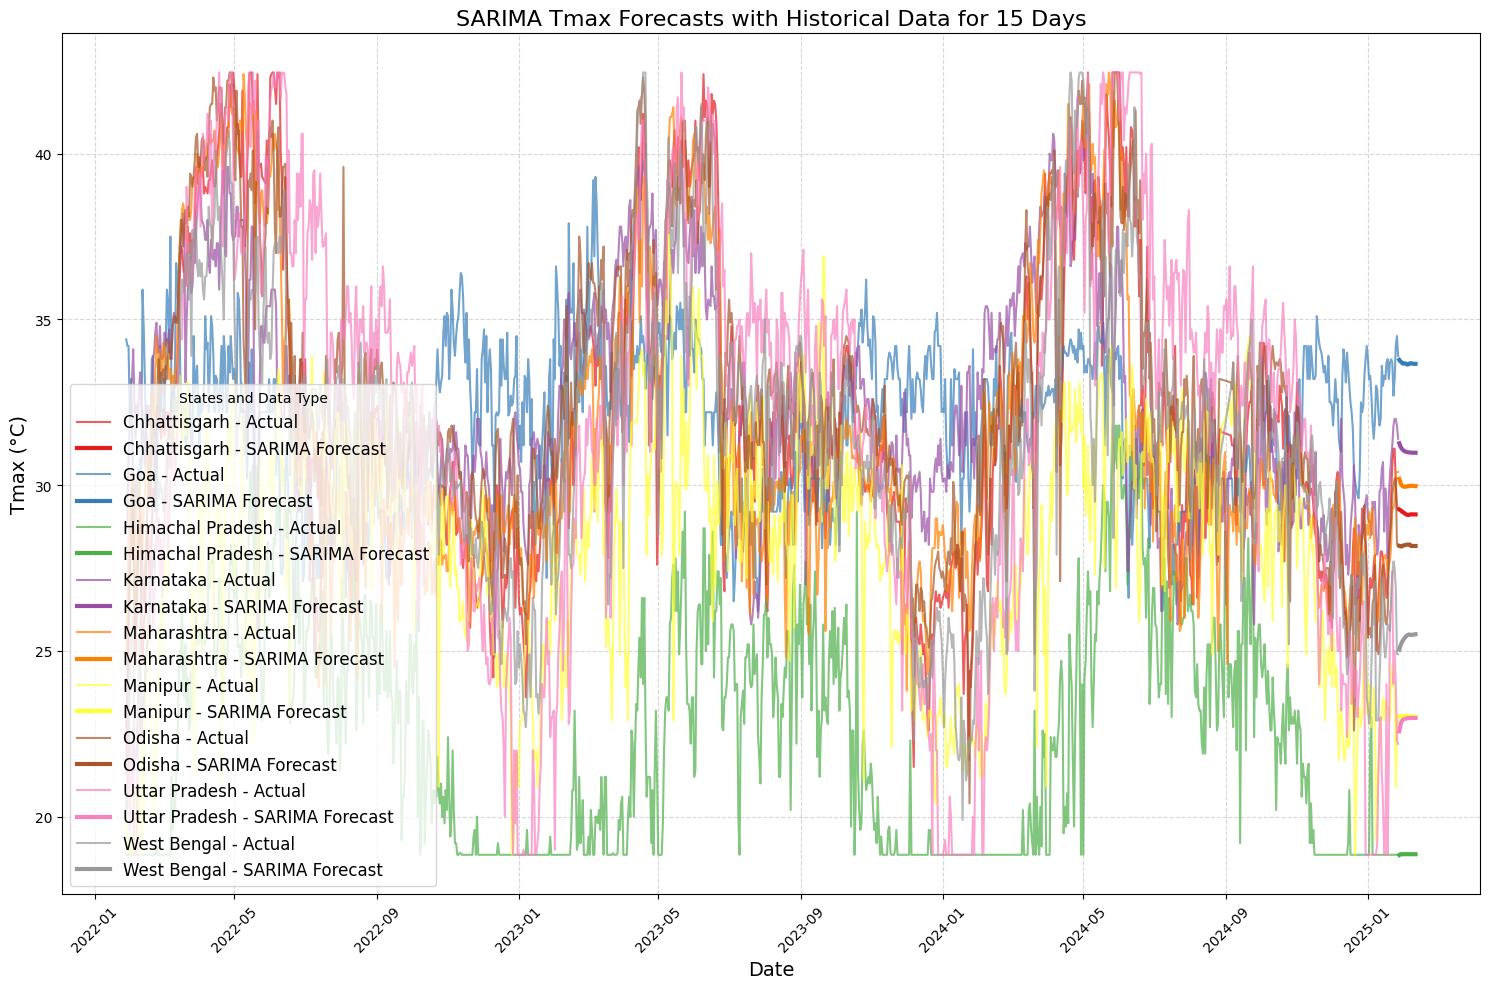

In [44]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_forecasts_with_thick_lines_sarima(df, forecast_results, states, forecast_days=15):
    """
    Plot the historical and SARIMA forecasted Tmax values for all states with unique colors and thick lines for forecasts.
    
    Parameters:
        df (pd.DataFrame): Original dataset containing 'tmax', 'state', and 'date'.
        forecast_results (dict): Dictionary containing SARIMA forecasted Tmax for each state.
        states (list): List of states.
        forecast_days (int): Number of forecast days.
    """
    plt.figure(figsize=(15, 10))
    
    # Generate a unique color map for the states
    colors = cm.get_cmap('Set1', len(states))  # Try other colormaps like 'viridis', 'Set1', etc.
    
    for i, state in enumerate(states):
        # Filter the historical data for the current state
        state_data = df[df['state'] == state].sort_index()
        
        # Plot historical Tmax values as regular lines
        plt.plot(
            state_data.index,
            state_data['tmax'],
            label=f"{state} - Actual",
            linestyle='-',
            color=colors(i),
            alpha=0.7,
            linewidth=1.5  # Regular line width for historical data
        )
        
        # Plot SARIMA forecasted Tmax values as thick lines
        forecast_df = forecast_results[state]
        plt.plot(
            forecast_df['date'],
            forecast_df['forecast_tmax'],
            label=f"{state} - SARIMA Forecast",
            linestyle='-',
            linewidth=3.0,  # Thicker line width for forecasted data
            color=colors(i)  # Use the same color as the historical line for consistency
        )
    
    # Plot styling
    plt.title(f"SARIMA Tmax Forecasts with Historical Data for {forecast_days} Days", fontsize=16)
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Tmax (°C)", fontsize=14)
    plt.legend(title="States and Data Type", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(visible=True, linestyle='--', alpha=0.5)
    plt.show()

# Call the function to plot the SARIMA forecasts with thick lines
plot_forecasts_with_thick_lines_sarima(df, forecast_results, states)


## Calculating the numeric terms for defining the accuracy

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
def calculate_accuracy_sarima(weather_df, all_sarima_forecasts):
    """
    Calculate accuracy metrics (MAE, MSE, RMSE, MAPE) for each state based on SARIMA forecasts.
    Parameters:
        weather_df (pd.DataFrame): Original dataset containing 'Date', 'State', and 'Max_Temperature' columns.
        all_sarima_forecasts (pd.DataFrame): Forecasted dataset containing 'date', 'state', and 'forecast_tmax' columns.
    Returns:
        pd.DataFrame: DataFrame containing accuracy metrics for each state.
    """
    # Rename columns for consistency
    weather_df = weather_df.rename(columns={'Date': 'date', 'State': 'state', 'Max_Temperature': 'tmax'})
    # Convert 'date' column to datetime in both DataFrames
    weather_df['date'] = pd.to_datetime(weather_df['date'])
    all_sarima_forecasts['date'] = pd.to_datetime(all_sarima_forecasts['date'])
    # Initialize a dictionary to store results
    accuracy_results = []
    # Loop through each state in the forecasted data
    for state in all_sarima_forecasts['state'].unique():
        # Filter actual and forecasted data for the state
        actual_data = weather_df[weather_df['state'] == state]
        forecast_data = all_sarima_forecasts[all_sarima_forecasts['state'] == state]
        # Merge actual and forecasted data on 'date'
        merged_data = pd.merge(
            actual_data[['date', 'tmax']],
            forecast_data[['date', 'forecast_tmax']],
            on='date',
            how='inner'
        )
        # Ensure there is data to compare
        if not merged_data.empty:
            # Calculate accuracy metrics
            mae = mean_absolute_error(merged_data['tmax'], merged_data['forecast_tmax'])
            mse = mean_squared_error(merged_data['tmax'], merged_data['forecast_tmax'])
            rmse = mse ** 0.5
            mape = (abs((merged_data['tmax'] - merged_data['forecast_tmax']) / merged_data['tmax'])).mean() * 100
            # Store the results
            accuracy_results.append({
                'State': state,
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse,
                'MAPE (%)': mape
            })
    # Convert results to a DataFrame
    accuracy_df = pd.DataFrame(accuracy_results)
    return accuracy_df
# Calculate accuracy for SARIMA forecasts
accuracy_df = calculate_accuracy_sarima(weather_df, all_sarima_forecasts)
# Print the accuracy DataFrame
print(accuracy_df)








              State        MAE         MSE       RMSE   MAPE (%)
0      Chhattisgarh   5.827876   42.732096   6.536979  18.960190
1               Goa   5.216108   38.325531   6.190762  18.789890
2  Himachal Pradesh  13.320151  206.407833  14.366901  39.499973
3         Karnataka   4.874775   33.404361   5.779651  19.145356
4       Maharashtra   4.409861   27.213527   5.216659  15.682334
5           Manipur   5.426891   52.652057   7.256174  17.205484
6            Odisha   4.286663   25.145760   5.014555  15.314667
7     Uttar Pradesh   8.097381  107.061244  10.347040  22.983148
8       West Bengal   6.974767   73.552111   8.576253  19.929981


## Accuracy of sarima model

In [46]:


# Calculate Accuracy based on MAPE
accuracy_df['Accuracy (%)'] = 100 - accuracy_df['MAPE (%)']
# Display the updated DataFrame
print(accuracy_df)



              State        MAE         MSE       RMSE   MAPE (%)  Accuracy (%)
0      Chhattisgarh   5.827876   42.732096   6.536979  18.960190     81.039810
1               Goa   5.216108   38.325531   6.190762  18.789890     81.210110
2  Himachal Pradesh  13.320151  206.407833  14.366901  39.499973     60.500027
3         Karnataka   4.874775   33.404361   5.779651  19.145356     80.854644
4       Maharashtra   4.409861   27.213527   5.216659  15.682334     84.317666
5           Manipur   5.426891   52.652057   7.256174  17.205484     82.794516
6            Odisha   4.286663   25.145760   5.014555  15.314667     84.685333
7     Uttar Pradesh   8.097381  107.061244  10.347040  22.983148     77.016852
8       West Bengal   6.974767   73.552111   8.576253  19.929981     80.070019


## overall accuracy of sarima model

In [47]:
# Overall accuracy as the mean of individual accuracies
overall_accuracy = accuracy_df['Accuracy (%)'].mean()
print(f"Overall Model Accuracy: {overall_accuracy:.2f}%")

Overall Model Accuracy: 79.17%


# 3.Exponential Smoothing

In [48]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# List of states (assuming your dataset contains a column 'state')
states = df['state'].unique()

# Dictionary to store models and AIC values for each state
model_results = {}

for state in states:
    # Filter the data for the current state
    state_data = df[df['state'] == state]['tmax'].sort_index()

    # Additive seasonality model
    add_model = ExponentialSmoothing(
        state_data, 
        trend='add',  # Additive trend (you can try 'mul' for multiplicative trend)
        seasonal='add',  # Additive seasonality
        seasonal_periods=12  # Assuming monthly seasonality (12 for yearly)
    ).fit()

   
    # Store the results in the dictionary
    model_results[state] = {
        'additive_model': add_model,
        
        'additive_aic': add_model.aic,
        
    }

    # Print AIC values to compare models
    print(f"\nState: {state}")
    print(f"Additive model AIC: {add_model.aic}")
   



State: Chhattisgarh
Additive model AIC: 580.9466195215097

State: Goa
Additive model AIC: 355.14319910421284

State: Himachal Pradesh
Additive model AIC: 756.9642322446239

State: Karnataka
Additive model AIC: 300.4941270710336

State: Maharashtra
Additive model AIC: 369.15546573118866

State: Manipur
Additive model AIC: 1227.6354769889354

State: Odisha
Additive model AIC: 736.8747063697698

State: Uttar Pradesh
Additive model AIC: 1019.6546297694719

State: West Bengal
Additive model AIC: 749.3144239901962


## Forecasting using Holt-winters additive model


Forecast for Chhattisgarh:
           date  forecast_tmax
1087 2025-01-28      29.179886
1088 2025-01-29      28.952154
1089 2025-01-30      28.986647
1090 2025-01-31      29.036456
1091 2025-02-01      29.024645
1092 2025-02-02      29.043633
1093 2025-02-03      29.034853
1094 2025-02-04      29.275477
1095 2025-02-05      29.385378
1096 2025-02-06      29.381512
1097 2025-02-07      29.415610
1098 2025-02-08      29.384273
1099 2025-02-09      29.264248
1100 2025-02-10      29.036516
1101 2025-02-11      29.071009

Forecast for Goa:
           date  forecast_tmax
1094 2025-01-28      34.080084
1095 2025-01-29      34.048216
1096 2025-01-30      34.073491
1097 2025-01-31      34.059205
1098 2025-02-01      34.095469
1099 2025-02-02      34.022942
1100 2025-02-03      34.054810
1101 2025-02-04      33.828437
1102 2025-02-05      34.036129
1103 2025-02-06      33.992173
1104 2025-02-07      33.930597
1105 2025-02-08      34.064293
1106 2025-02-09      34.077120
1107 2025-02-10      34

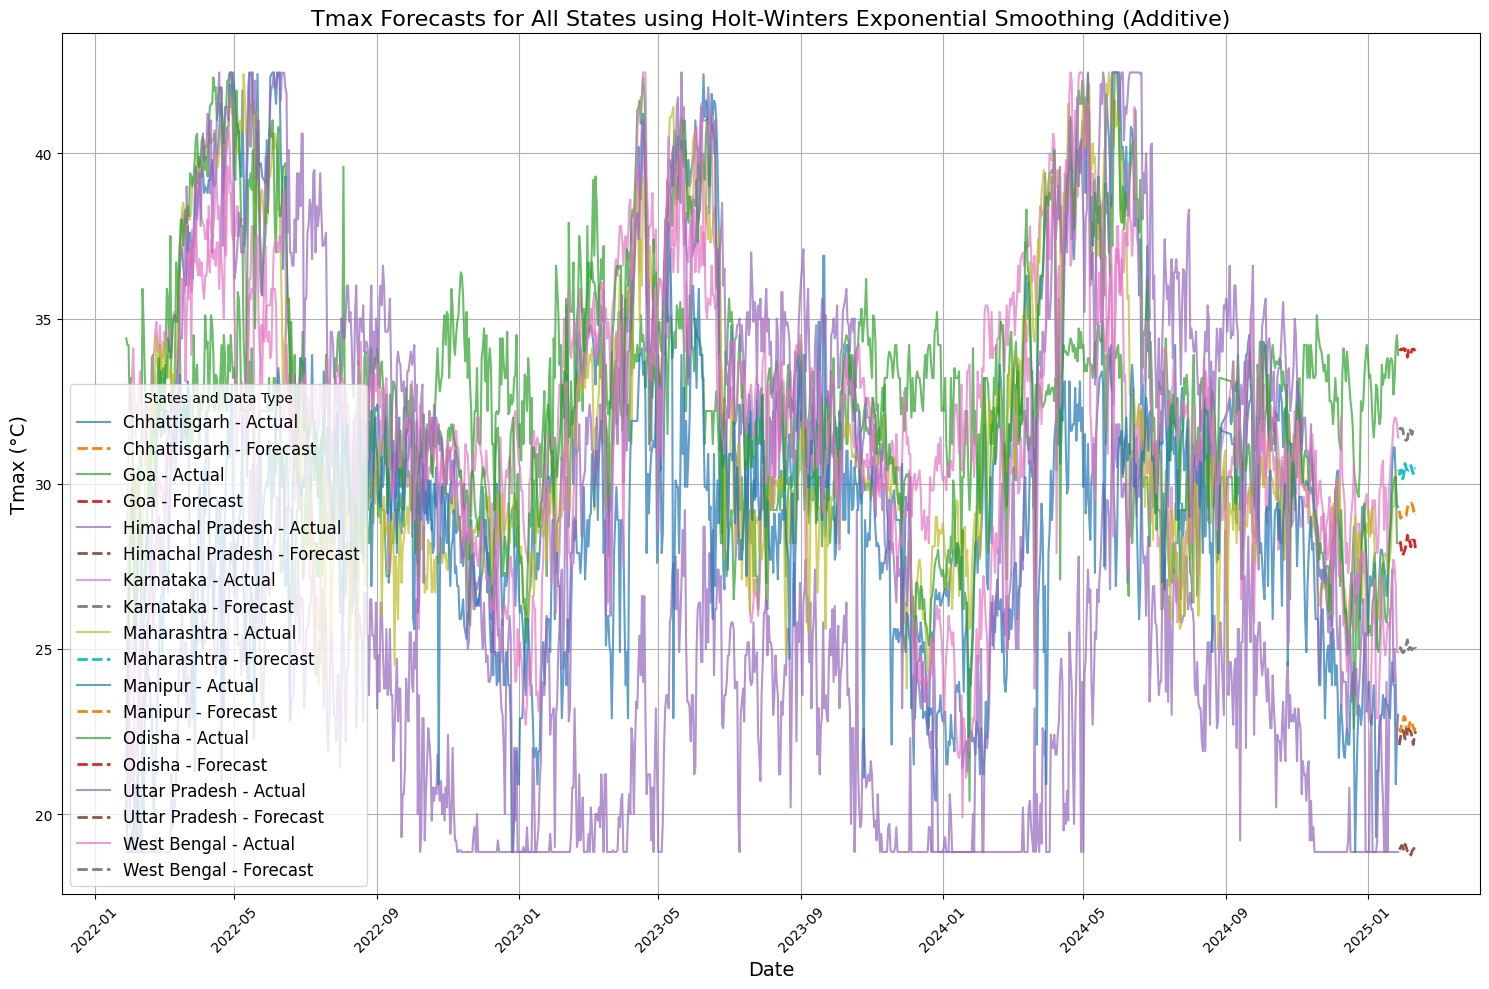

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# List of states (as per your data)
states = ['Chhattisgarh', 'Goa', 'Himachal Pradesh', 'Karnataka', 
          'Maharashtra', 'Manipur', 'Odisha', 'Uttar Pradesh', 'West Bengal']

# Dictionary to store forecast results for each state
forecast_results = {}

# Forecast function for all states using Holt-Winters Exponential Smoothing (Additive)
def forecast_tmax_for_state(state_name, df, forecast_days=15):
    """
    Forecast Tmax for a specific state using Holt-Winters Exponential Smoothing model (Additive).
    
    Parameters:
        state_name (str): The state to forecast for.
        df (pd.DataFrame): The full dataset containing 'tmax' and 'state'.
        forecast_days (int): Number of days to forecast.
        
    Returns:
        pd.DataFrame: DataFrame containing forecasted Tmax for the state.
    """
    # Filter the data for the specific state
    state_data = df[df['state'] == state_name]['tmax'].sort_index()

    # Fit the Holt-Winters model with additive trend and seasonality
    add_model = ExponentialSmoothing(
        state_data, 
        trend='add',  # Additive trend component
        seasonal='add',  # Additive seasonal component
        seasonal_periods=12  # Assuming monthly seasonality (adjust if necessary)
    ).fit()

    # Forecast for the next `forecast_days` days
    forecast = add_model.forecast(steps=forecast_days)

    # Create a DataFrame for the forecast results
    forecast_index = pd.date_range(start=state_data.index[-1] + pd.Timedelta(days=1), periods=forecast_days)
    forecast_df = pd.DataFrame({
        'date': forecast_index,
        'forecast_tmax': forecast
    })

    # Return the forecast DataFrame
    return forecast_df

# Generate forecasts for all states
for state in states:
    forecast_results[state] = forecast_tmax_for_state(state, df)

# Combine the forecasts for all states into a single DataFrame
all_holt_forecasts = pd.concat([forecast_results[state].assign(state=state) for state in states])

# Print the forecast for each state
for state in states:
    print(f"\nForecast for {state}:")
    print(forecast_results[state])

# Plot the forecast for each state
plt.figure(figsize=(15, 10))

# Loop to plot each state's forecast separately
for i, state in enumerate(states):
    # Historical data for the state
    state_data = df[df['state'] == state].sort_index()
    
    # Plot historical Tmax values
    plt.plot(state_data.index, state_data['tmax'], label=f'{state} - Actual', linestyle='-', alpha=0.7)

    # Forecasted Tmax values for the state
    forecast_df = forecast_results[state]
    plt.plot(forecast_df['date'], forecast_df['forecast_tmax'], label=f'{state} - Forecast', linestyle='--', linewidth=2)

# Add titles and labels
plt.title("Tmax Forecasts for All States using Holt-Winters Exponential Smoothing (Additive)", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Tmax (°C)", fontsize=14)
plt.legend(title="States and Data Type", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()


## Calculating the numeric terms to define accuracy

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd

def calculate_accuracy_holt(weather_df, all_holt_forecasts):
    """
    Calculate accuracy metrics (MAE, MSE, RMSE, MAPE) for each state based on Holt-Winters forecasts.
    Parameters:
        weather_df (pd.DataFrame): Original dataset containing 'Date', 'State', and 'Max_Temperature' columns.
        all_holt_forecasts (pd.DataFrame): Forecasted dataset containing 'date', 'state', and 'forecast_tmax' columns.
    Returns:
        pd.DataFrame: DataFrame containing accuracy metrics for each state.
    """
    # Rename columns for consistency
    weather_df = weather_df.rename(columns={'Date': 'date', 'State': 'state', 'Max_Temperature': 'tmax'})
    
    # Convert 'date' column to datetime in both DataFrames
    weather_df['date'] = pd.to_datetime(weather_df['date'])
    all_holt_forecasts['date'] = pd.to_datetime(all_holt_forecasts['date'])
    
    # Initialize a dictionary to store results
    accuracy_results = []
    
    # Loop through each state in the forecasted data
    for state in all_holt_forecasts['state'].unique():
        # Filter actual and forecasted data for the state
        actual_data = weather_df[weather_df['state'] == state]
        forecast_data = all_holt_forecasts[all_holt_forecasts['state'] == state]
        
        # Merge actual and forecasted data on 'date'
        merged_data = pd.merge(
            actual_data[['date', 'tmax']],
            forecast_data[['date', 'forecast_tmax']],
            on='date',
            how='inner'
        )
        
        # Ensure there is data to compare
        if not merged_data.empty:
            # Calculate accuracy metrics
            mae = mean_absolute_error(merged_data['tmax'], merged_data['forecast_tmax'])
            mse = mean_squared_error(merged_data['tmax'], merged_data['forecast_tmax'])
            rmse = mse ** 0.5
            mape = (abs((merged_data['tmax'] - merged_data['forecast_tmax']) / merged_data['tmax'])).mean() * 100
            
            # Store the results
            accuracy_results.append({
                'State': state,
                'MAE': mae,
                'MSE': mse,
                'RMSE': rmse,
                'MAPE (%)': mape
            })
    
    # Convert results to a DataFrame
    accuracy_df = pd.DataFrame(accuracy_results)
    return accuracy_df

# Calculate accuracy for Holt-Winters forecasts
accuracy_df = calculate_accuracy_holt(weather_df, all_holt_forecasts)

# Print the accuracy DataFrame
print(accuracy_df)


              State        MAE         MSE       RMSE   MAPE (%)
0      Chhattisgarh   5.852654   43.438172   6.590764  19.027988
1               Goa   5.288233   40.014368   6.325691  19.203255
2  Himachal Pradesh  13.254637  204.858274  14.312871  39.278785
3         Karnataka   5.042439   35.988654   5.999054  19.952805
4       Maharashtra   4.620721   28.410018   5.330105  16.589181
5           Manipur   5.524635   56.506532   7.517083  17.339110
6            Odisha   4.269816   25.035550   5.003554  15.227494
7     Uttar Pradesh   8.417767  114.527311  10.701743  23.912075
8       West Bengal   7.091565   76.538118   8.748607  20.173942


## Accuracy of each state

In [51]:
# Calculate Accuracy based on MAPE
accuracy_df['Accuracy (%)'] = 100 - accuracy_df['MAPE (%)']
# Display the updated DataFrame
print(accuracy_df)


              State        MAE         MSE       RMSE   MAPE (%)  Accuracy (%)
0      Chhattisgarh   5.852654   43.438172   6.590764  19.027988     80.972012
1               Goa   5.288233   40.014368   6.325691  19.203255     80.796745
2  Himachal Pradesh  13.254637  204.858274  14.312871  39.278785     60.721215
3         Karnataka   5.042439   35.988654   5.999054  19.952805     80.047195
4       Maharashtra   4.620721   28.410018   5.330105  16.589181     83.410819
5           Manipur   5.524635   56.506532   7.517083  17.339110     82.660890
6            Odisha   4.269816   25.035550   5.003554  15.227494     84.772506
7     Uttar Pradesh   8.417767  114.527311  10.701743  23.912075     76.087925
8       West Bengal   7.091565   76.538118   8.748607  20.173942     79.826058


## overall accuracy

In [52]:
# Overall accuracy as the mean of individual accuracies
overall_accuracy = accuracy_df['Accuracy (%)'].mean()
print(f"Overall Model Accuracy: {overall_accuracy:.2f}%")

Overall Model Accuracy: 78.81%


## 4.LSTM model

In [53]:
# Assuming 'df' has 'index' as the date column


# Now you can proceed with the rest of your code as usual
# For example, normalize and create sequences
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['tmax'].values.reshape(-1, 1))

# Create sequences of data
def create_sequences(data, seq_length=30):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

seq_length = 30
X = create_sequences(scaled_data, seq_length)
y = scaled_data[seq_length:]

# Split data into train and test
X_train, X_test = X[:-15], X[-15:]
y_train, y_test = y[:-15], y[-15:]

# Build the LSTM model (assuming you have already set up the model as shown previously)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

# Forecast
y_pred = model.predict(X_test)

# Inverse scale the predictions
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test)

# Calculate accuracy metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
rmse = mse ** 0.5
mape = (abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)).mean() * 100

print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}, MAPE: {mape}%")





Epoch 1/20

306/306 [==============================] - 9s 18ms/step - loss: 0.0123
Epoch 2/20
306/306 [==============================] - 6s 18ms/step - loss: 0.0062
Epoch 3/20
306/306 [==============================] - 6s 19ms/step - loss: 0.0051
Epoch 4/20
306/306 [==============================] - 6s 20ms/step - loss: 0.0041
Epoch 5/20
306/306 [==============================] - 6s 20ms/step - loss: 0.0037
Epoch 6/20
306/306 [==============================] - 6s 19ms/step - loss: 0.0036
Epoch 7/20
306/306 [==============================] - 6s 20ms/step - loss: 0.0036
Epoch 8/20
306/306 [==============================] - 7s 22ms/step - loss: 0.0035
Epoch 9/20
306/306 [==============================] - 6s 20ms/step - loss: 0.0035
Epoch 10/20
306/306 [==============================] - 6s 19ms/step - loss: 0.0036
Epoch 11/20
306/306 [==============================] - 6s 19ms/step - loss: 0.0036
Epoch 12/20
306/306 [==============================] - 6s 19ms/step - loss: 0.0036
Epoch 13/

## Forecasting using LSTM model

In [55]:
# Reset index if 'date' is the index
if df.index.name == 'index' or isinstance(df.index, pd.DatetimeIndex):
    df.reset_index(inplace=True)


# Now we can proceed with the forecasting
def forecast_state_tmax(df, state_name, model, scaler, seq_length=30, forecast_periods=15):
    """
    Forecast future Tmax values for a given state using the trained LSTM model.
    Parameters:
        df (pd.DataFrame): The main DataFrame containing 'date', 'state', and 'tmax' columns.
        state_name (str): The state name for which the forecast should be made.
        model (keras.model): The trained LSTM model.
        scaler (sklearn.preprocessing.MinMaxScaler): The scaler used for normalizing the data.
        seq_length (int): The number of time steps to consider for each input sequence.
        forecast_periods (int): The number of future periods to forecast.
    Returns:
        pd.DataFrame: DataFrame containing forecasted Tmax values for the state.
    """
    # Filter data for the given state
    state_data = df[df['state'] == state_name]

    # Normalize the Tmax data for the state
    scaled_state_data = scaler.fit_transform(state_data['tmax'].values.reshape(-1, 1))

    # Get the last sequence from the state data (most recent sequence)
    last_sequence = scaled_state_data[-seq_length:]

    # Forecast future Tmax values
    forecasted_values = []

    # Use the last sequence as input to predict the next values
    input_sequence = last_sequence.reshape((1, last_sequence.shape[0], 1))

    for _ in range(forecast_periods):
        # Predict the next value
        next_value = model.predict(input_sequence)
        
        # Append the predicted value to the forecasted values list
        forecasted_values.append(next_value[0, 0])

        # Update the input sequence for the next prediction
        input_sequence = np.append(input_sequence[:, 1:, :], next_value.reshape(1, 1, 1), axis=1)

    # Inverse scale the forecasted values to the original scale
    forecasted_values_rescaled = scaler.inverse_transform(np.array(forecasted_values).reshape(-1, 1))

    # Generate a list of forecasted dates for the next `forecast_periods` days
    last_date = state_data['index'].iloc[-1]  # Last date from the state data
    forecast_dates = pd.date_range(last_date, periods=forecast_periods + 1, freq='D')[1:]

    # Prepare the forecasted data as a DataFrame
    forecast_df = pd.DataFrame({
        'date': forecast_dates,
        'forecast_tmax': forecasted_values_rescaled.flatten()
    })

    return forecast_df

# Example list of states (adjust as per your dataset)
states = df['state'].unique()

# Initialize a dictionary to store forecasted results for each state
forecast_results = {}

# Forecast Tmax for each state
for state in states:
    forecast_results[state] = forecast_state_tmax(df, state, model, scaler, seq_length=30, forecast_periods=15)

# Display forecasted Tmax values for each state
for state, forecast_df in forecast_results.items():
    print(f"Forecast for {state}:")
    print(forecast_df)
    print("\n")


1/1 [==============================] - 0s 25ms/step
Forecast for Chhattisgarh:
         date  forecast_tmax
0  2025-01-28      28.974018
1  2025-01-29      28.737364
2  2025-01-30      28.550556
3  2025-01-31      28.390078
4  2025-02-01      28.243195
5  2025-02-02      28.103224
6  2025-02-03      27.966572
7  2025-02-04      27.831469
8  2025-02-05      27.697334
9  2025-02-06      27.564220
10 2025-02-07      27.432388
11 2025-02-08      27.301880
12 2025-02-09      27.173244
13 2025-02-10      27.046852
14 2025-02-11      26.922970


Forecast for Goa:
         date  forecast_tmax
0  2025-01-28      33.456055
1  2025-01-29      33.131310
2  2025-01-30      32.880817
3  2025-01-31      32.677692
4  2025-02-01      32.504314
5  2025-02-02      32.349018
6  2025-02-03      32.204540
7  2025-02-04      32.066528
8  2025-02-05      31.932573
9  2025-02-06      31.801525
10 2025-02-07      31.673004
11 2025-02-08      31.547010
12 2025-02-09      31.423563
13 2025-02-10      31.302698
14

## Visualizing the forecast

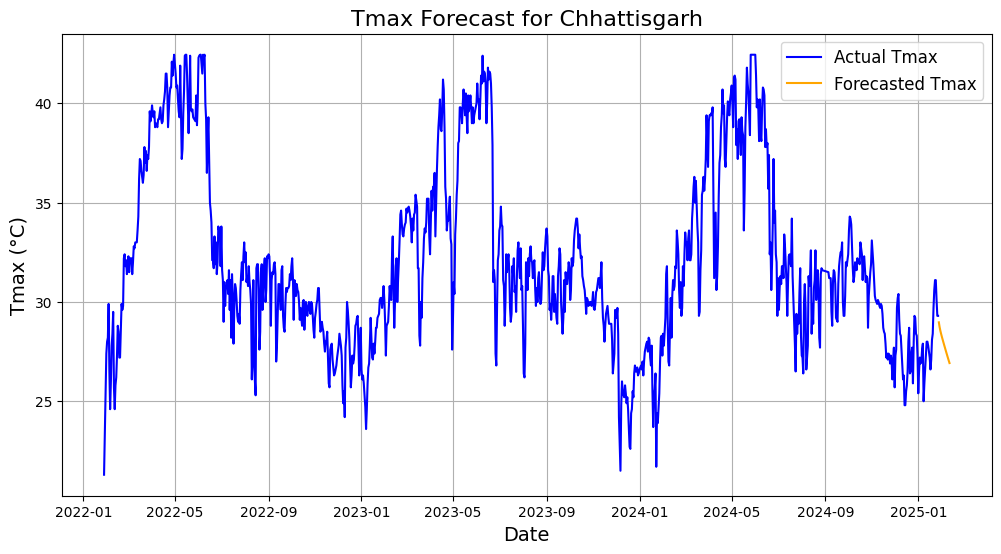

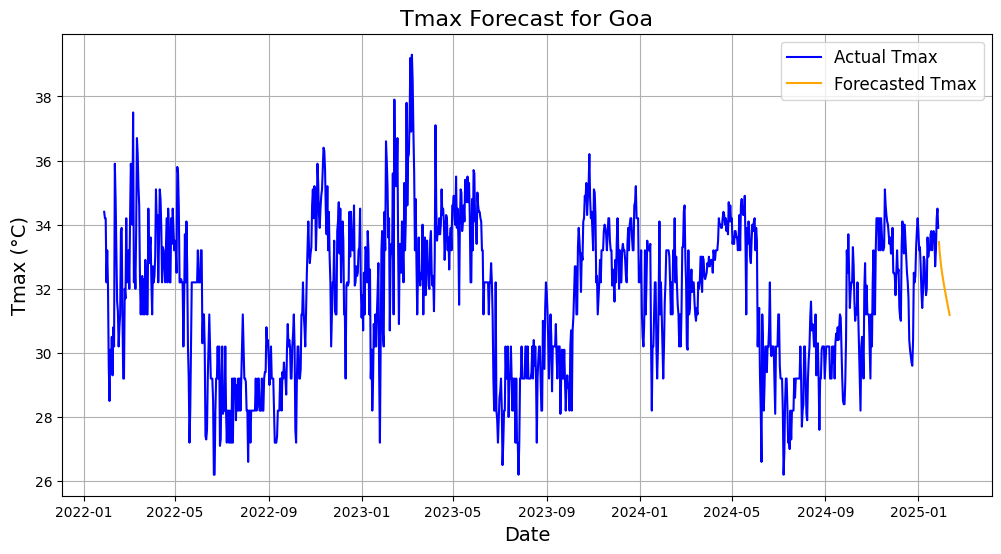

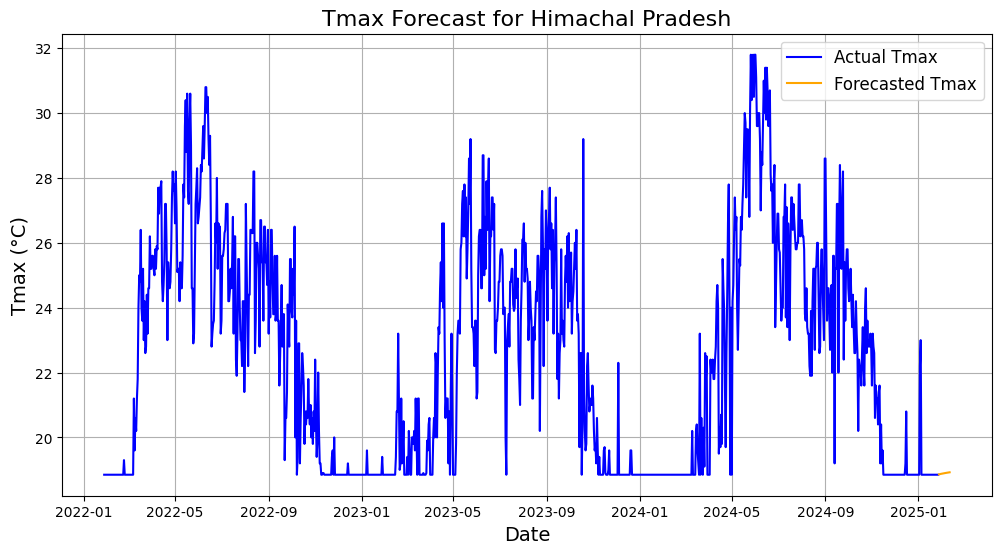

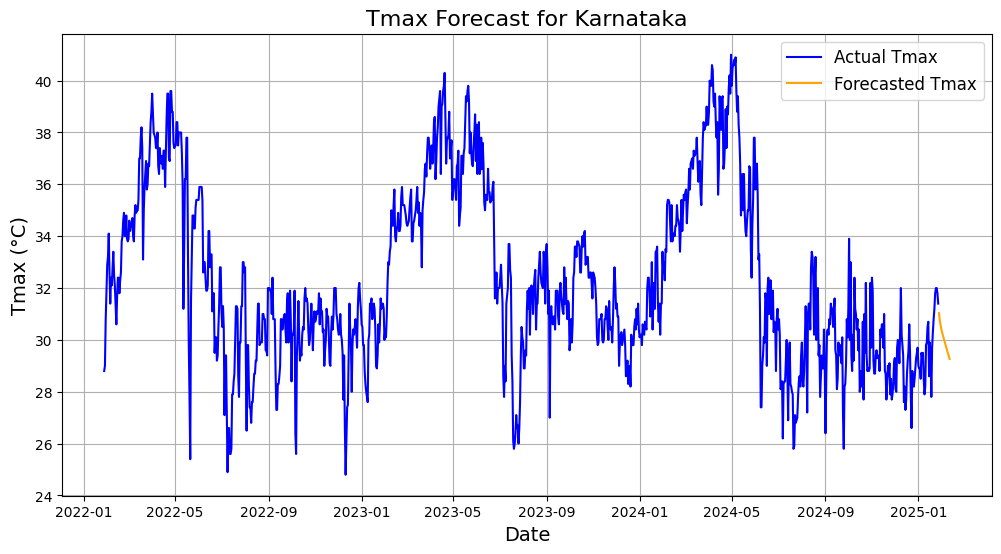

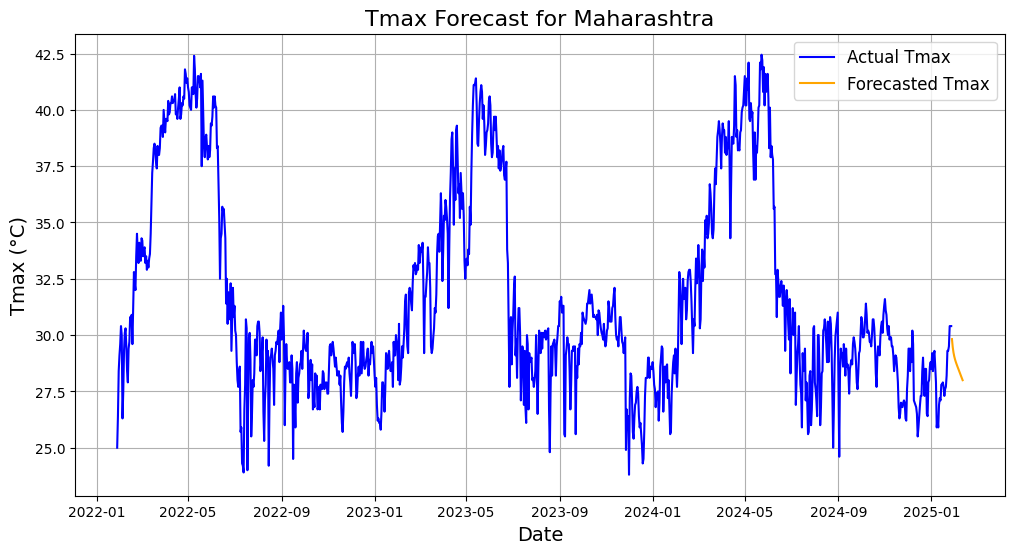

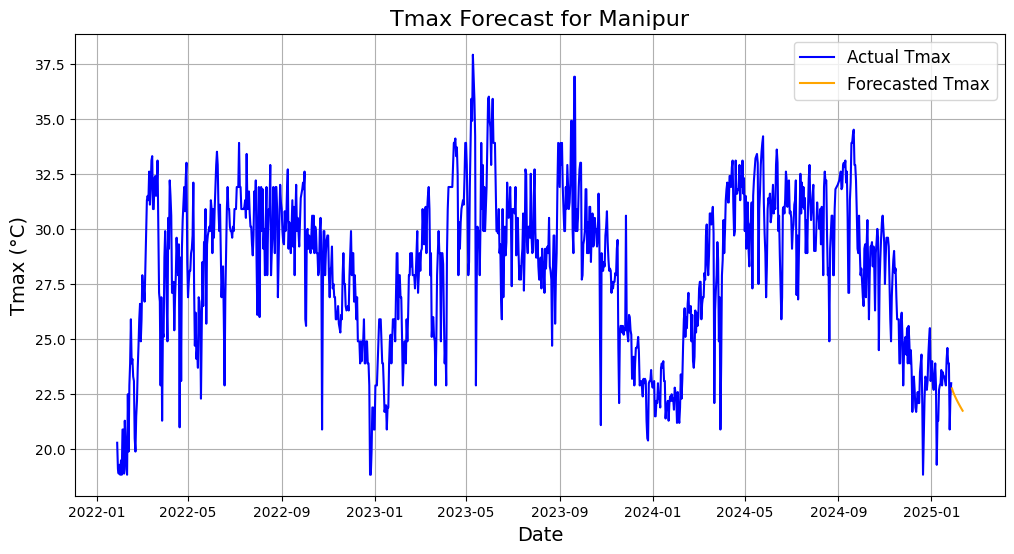

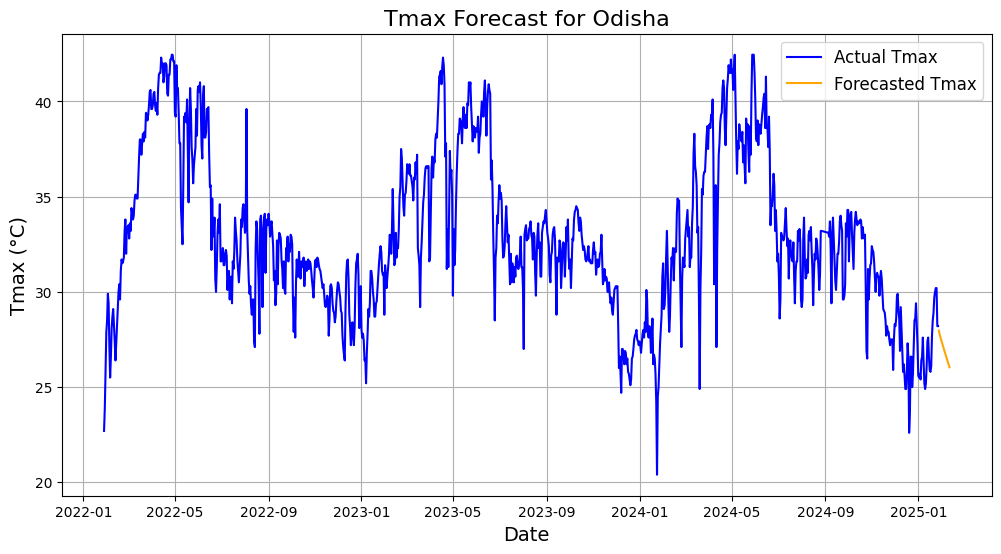

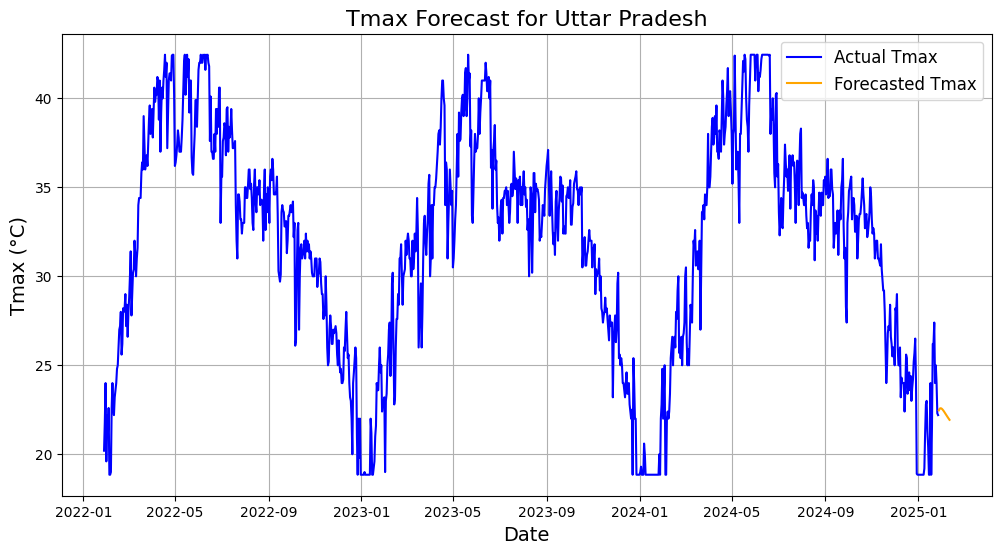

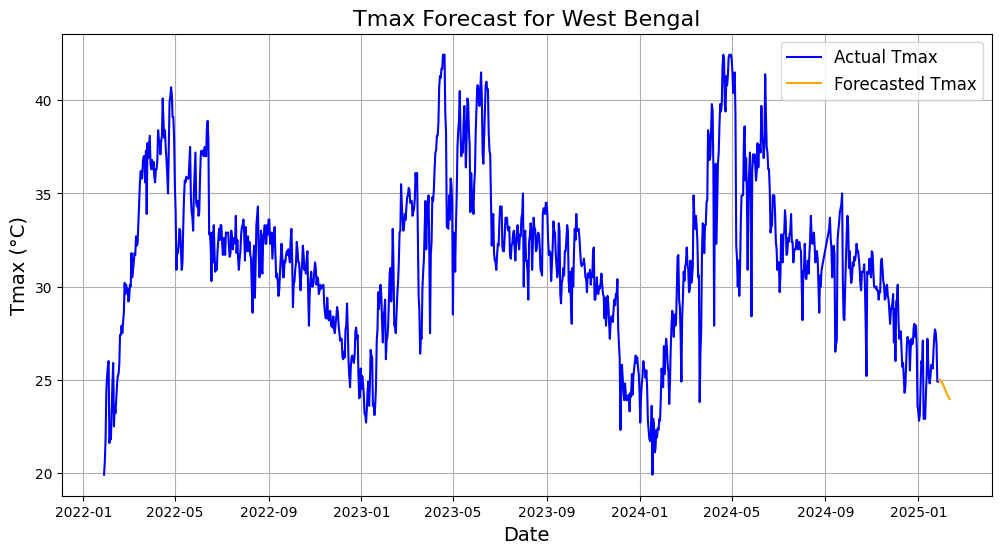

In [57]:
import matplotlib.pyplot as plt

def visualize_forecast(df, forecast_results, states):
    """
    Visualize the actual and forecasted Tmax values for each state.
    Parameters:
        df (pd.DataFrame): The main DataFrame containing actual Tmax values.
        forecast_results (dict): A dictionary of forecasted DataFrames for each state.
        states (list): List of states to visualize.
    """
    for state in states:
        # Filter the original data for the state
        state_data = df[df['state'] == state]

        # Extract the forecasted data for the state
        forecast_df = forecast_results[state]

        # Plot the actual Tmax values
        plt.figure(figsize=(12, 6))
        plt.plot(state_data['index'], state_data['tmax'], label="Actual Tmax", color="blue")

        # Plot the forecasted Tmax values
        plt.plot(forecast_df['date'], forecast_df['forecast_tmax'], label="Forecasted Tmax", color="orange")

        # Add titles and labels
        plt.title(f"Tmax Forecast for {state}", fontsize=16)
        plt.xlabel("Date", fontsize=14)
        plt.ylabel("Tmax (°C)", fontsize=14)
        plt.legend(fontsize=12)
        plt.grid(True)

        # Show the plot
        plt.show()

# Call the visualization function
visualize_forecast(df, forecast_results, states)


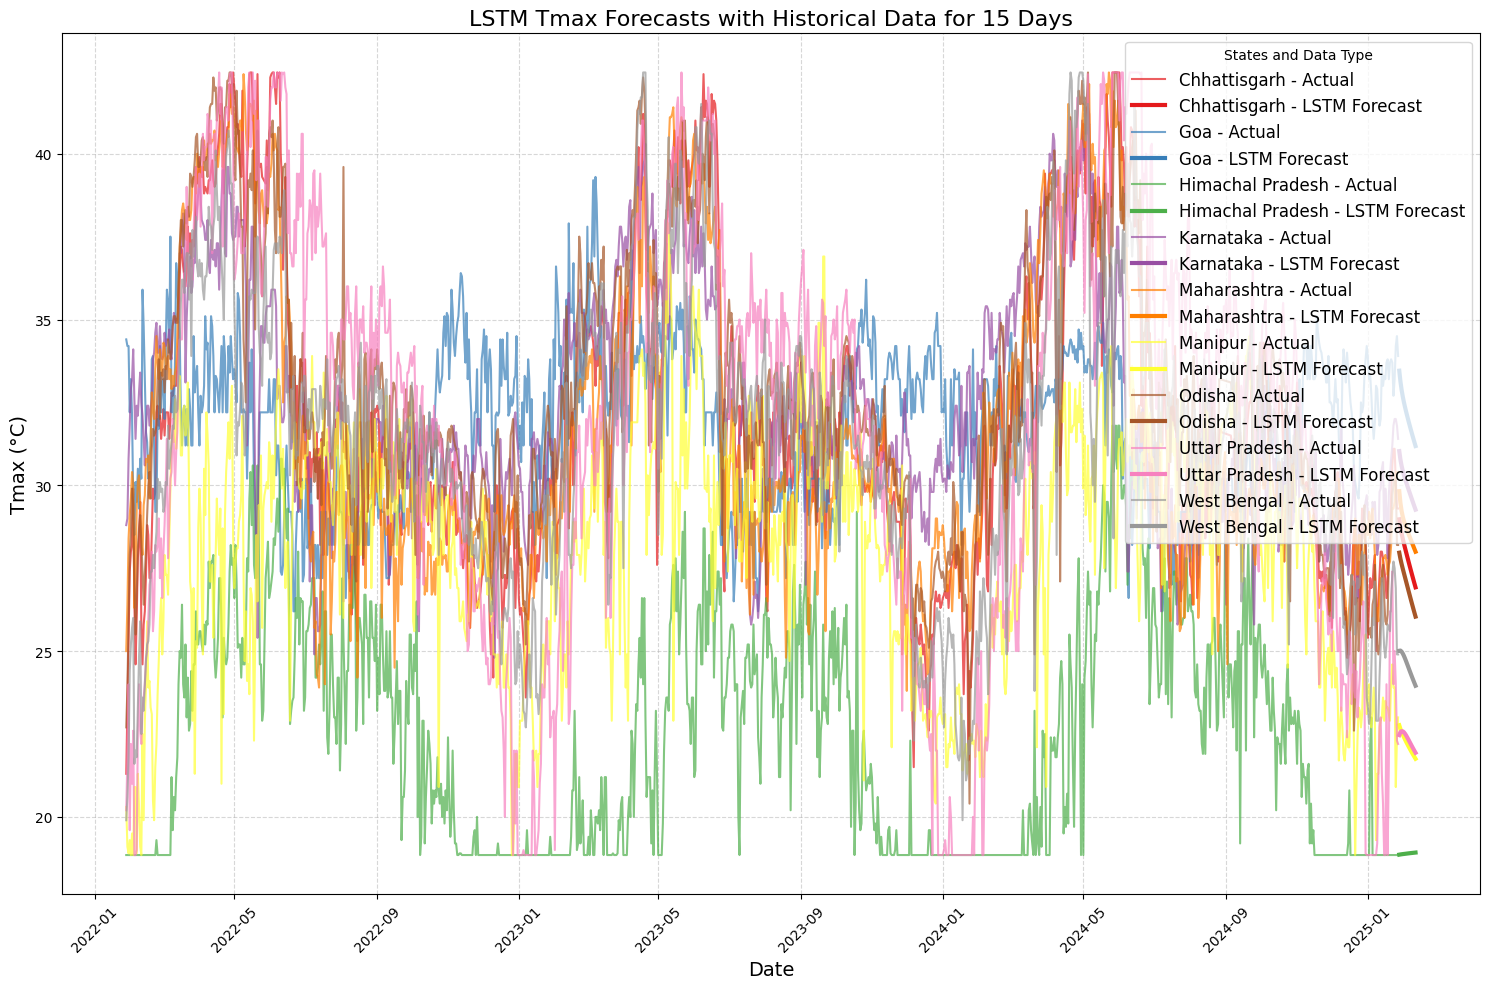

In [62]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_forecasts_with_thick_lines_lstm(df, forecast_results, states, forecast_days=15):
    """
    Plot the historical and LSTM forecasted Tmax values for all states with unique colors and thick lines for forecasts.
    
    Parameters:
        df (pd.DataFrame): Original dataset containing 'tmax', 'state', and 'date'.
        forecast_results (dict): Dictionary containing LSTM forecasted Tmax for each state.
        states (list): List of states.
        forecast_days (int): Number of forecast days.
    """
    plt.figure(figsize=(15, 10))
    
    # Generate a unique color map for the states
    colors = cm.get_cmap('Set1', len(states))  # Try other colormaps like 'viridis', 'Set1', etc.
    
    for i, state in enumerate(states):
        # Filter the historical data for the current state
        state_data = df[df['state'] == state].sort_values(by='index')
        
        # Plot historical Tmax values as regular lines
        plt.plot(
            state_data['index'],
            state_data['tmax'],
            label=f"{state} - Actual",
            linestyle='-',
            color=colors(i),
            alpha=0.7,
            linewidth=1.5  # Regular line width for historical data
        )
        
        # Plot LSTM forecasted Tmax values as thick lines
        forecast_df = forecast_results[state]
        plt.plot(
            forecast_df['date'],
            forecast_df['forecast_tmax'],
            label=f"{state} - LSTM Forecast",
            linestyle='-',
            linewidth=3.0,  # Thicker line width for forecasted data
            color=colors(i)  # Use the same color as the historical line for consistency
        )
    
    # Plot styling
    plt.title(f"LSTM Tmax Forecasts with Historical Data for {forecast_days} Days", fontsize=16)
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Tmax (°C)", fontsize=14)
    plt.legend(title="States and Data Type", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid(visible=True, linestyle='--', alpha=0.5)
    plt.show()

# Call the function to plot the LSTM forecasts with thick lines
plot_forecasts_with_thick_lines_lstm(df, forecast_results, states)


## Calculating the metrices of accuracy

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def calculate_accuracy_metrics(df, forecast_results, states):
    """
    Calculate accuracy metrics for LSTM forecasts for all states.
    
    Parameters:
        df (pd.DataFrame): Original dataset containing 'tmax', 'state', and 'date'.
        forecast_results (dict): Dictionary containing LSTM forecasted Tmax for each state.
        states (list): List of states.
    
    Returns:
        pd.DataFrame: DataFrame containing accuracy metrics for each state.
    """
    metrics = {
        'State': [],
        'MAE': [],
        'RMSE': [],
        'MAPE': [],
        'R2_Score': []
    }
    
    for state in states:
        # Filter historical data for the current state
        state_data = df[df['state'] == state].sort_values(by='index')
        
        # Get the actual Tmax values for the forecasted period
        actual_values = state_data['tmax'][-len(forecast_results[state]):].values
        
        # Get the forecasted Tmax values
        forecast_df = forecast_results[state]
        forecast_values = forecast_df['forecast_tmax'].values
        
        # Calculate metrics
        mae = mean_absolute_error(actual_values, forecast_values)
        rmse = np.sqrt(mean_squared_error(actual_values, forecast_values))
        mape = np.mean(np.abs((actual_values - forecast_values) / actual_values)) * 100
        r2 = r2_score(actual_values, forecast_values)
        
        # Append metrics to the dictionary
        metrics['State'].append(state)
        metrics['MAE'].append(mae)
        metrics['RMSE'].append(rmse)
        metrics['MAPE'].append(mape)
        metrics['R2_Score'].append(r2)
    
    # Convert metrics dictionary to a DataFrame for better visualization
    metrics_df = pd.DataFrame(metrics)
    
    return metrics_df

# Call the function to calculate accuracy metrics
metrics_df = calculate_accuracy_metrics(df, forecast_results, states)

# Display the accuracy metrics
print(metrics_df)


              State       MAE      RMSE       MAPE      R2_Score
0      Chhattisgarh  1.837434  2.141517   6.239833 -1.212703e+00
1               Goa  1.441831  1.710058   4.267913 -1.318033e+01
2  Himachal Pradesh  0.045207  0.049114   0.239823 -1.911132e+26
3         Karnataka  1.417746  1.669755   4.627946 -8.436433e-01
4       Maharashtra  1.470175  1.607737   5.131965 -9.409419e-01
5           Manipur  1.143059  1.310265   4.866440 -1.522389e+00
6            Odisha  1.909178  2.222723   6.659704 -1.240701e+00
7     Uttar Pradesh  2.451549  2.846848  10.855745 -1.025655e-01
8       West Bengal  1.531133  1.884024   5.729497 -2.556820e+00


## Calculating the accuracy

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
def calculate_accuracy_metrics_with_accuracy(df, forecast_results, states):
    """
    Calculate accuracy metrics and accuracy (%) for LSTM forecasts for all states.
    Parameters:
        df (pd.DataFrame): Original dataset containing 'tmax', 'state', and 'date'.
        forecast_results (dict): Dictionary containing LSTM forecasted Tmax for each state.
        states (list): List of states.
    Returns:
        pd.DataFrame: DataFrame containing accuracy metrics and accuracy (%) for each state.
    """
    metrics = {
        'State': [],
        'MAE': [],
        'RMSE': [],
        'MAPE': [],
        'R2_Score': [],
        'Accuracy (%)': []
    }
    for state in states:
        # Filter historical data for the current state
        state_data = df[df['state'] == state].sort_values(by='index')
        # Get the actual Tmax values for the forecasted period
        actual_values = state_data['tmax'][-len(forecast_results[state]):].values
        # Get the forecasted Tmax values
        forecast_df = forecast_results[state]
        forecast_values = forecast_df['forecast_tmax'].values
        # Calculate metrics
        mae = mean_absolute_error(actual_values, forecast_values)
        rmse = np.sqrt(mean_squared_error(actual_values, forecast_values))
        mape = np.mean(np.abs((actual_values - forecast_values) / actual_values)) * 100
        r2 = r2_score(actual_values, forecast_values)
        accuracy = 100 - mape  # Calculate accuracy
        # Append metrics to the dictionary
        metrics['State'].append(state)
        metrics['MAE'].append(mae)
        metrics['RMSE'].append(rmse)
        metrics['MAPE'].append(mape)
        metrics['R2_Score'].append(r2)
        metrics['Accuracy (%)'].append(accuracy)
    # Convert metrics dictionary to a DataFrame for better visualization
    metrics_df = pd.DataFrame(metrics)
    return metrics_df
# Call the function to calculate accuracy metrics
metrics_df = calculate_accuracy_metrics_with_accuracy(df, forecast_results, states)
# Display the accuracy metrics
print(metrics_df)



              State       MAE      RMSE       MAPE      R2_Score  Accuracy (%)
0      Chhattisgarh  1.837434  2.141517   6.239833 -1.212703e+00     93.760167
1               Goa  1.441831  1.710058   4.267913 -1.318033e+01     95.732087
2  Himachal Pradesh  0.045207  0.049114   0.239823 -1.911132e+26     99.760177
3         Karnataka  1.417746  1.669755   4.627946 -8.436433e-01     95.372054
4       Maharashtra  1.470175  1.607737   5.131965 -9.409419e-01     94.868035
5           Manipur  1.143059  1.310265   4.866440 -1.522389e+00     95.133560
6            Odisha  1.909178  2.222723   6.659704 -1.240701e+00     93.340296
7     Uttar Pradesh  2.451549  2.846848  10.855745 -1.025655e-01     89.144255
8       West Bengal  1.531133  1.884024   5.729497 -2.556820e+00     94.270503


In [70]:
# Calculate Accuracy based on MAPE
metrics_df['Accuracy (%)'] = 100 - metrics_df['MAPE']
# Display the updated DataFrame
print(metrics_df)

              State       MAE      RMSE       MAPE      R2_Score  Accuracy (%)
0      Chhattisgarh  1.837434  2.141517   6.239833 -1.212703e+00     93.760167
1               Goa  1.441831  1.710058   4.267913 -1.318033e+01     95.732087
2  Himachal Pradesh  0.045207  0.049114   0.239823 -1.911132e+26     99.760177
3         Karnataka  1.417746  1.669755   4.627946 -8.436433e-01     95.372054
4       Maharashtra  1.470175  1.607737   5.131965 -9.409419e-01     94.868035
5           Manipur  1.143059  1.310265   4.866440 -1.522389e+00     95.133560
6            Odisha  1.909178  2.222723   6.659704 -1.240701e+00     93.340296
7     Uttar Pradesh  2.451549  2.846848  10.855745 -1.025655e-01     89.144255
8       West Bengal  1.531133  1.884024   5.729497 -2.556820e+00     94.270503


## Overall accuracy

In [71]:
def calculate_overall_accuracy(metrics_df):
    """
    Calculate the overall model accuracy as the average accuracy across all states.
    Parameters:
        metrics_df (pd.DataFrame): DataFrame containing accuracy metrics for each state.
    Returns:
        float: The overall model accuracy.
    """
    # Calculate the mean of the 'Accuracy (%)' column
    overall_accuracy = metrics_df['Accuracy (%)'].mean()
    return overall_accuracy
# Call the function to calculate overall accuracy
overall_accuracy = calculate_overall_accuracy(metrics_df)
# Display the overall accuracy
print(f"Overall Model Accuracy: {overall_accuracy:.2f}%")

Overall Model Accuracy: 94.60%


# accuracies of all the models
# ARIMA model-79.81%
# Sarima -79.17%
# Holt-winters exponential smoothing-78.81%
# LSTM model-94.6%
 # so as i got 90% accuracy with LSTM model,the best model for my data is LSTM


## SQL connection

In [74]:
import mysql.connector
import pandas as pd  # Ensure pandas is imported

# Database connection details
db_config = {
    'host': 'localhost',
    'user': 'root',        # Replace with your MySQL username
    'password': 'root',    # Replace with your MySQL password
    'database': 'projects'  # Replace with your database name
}

# Connect to the database
connection = mysql.connector.connect(**db_config)
cursor = connection.cursor()

# Create the table if it doesn't exist
table_name = 'weather_data_nine_states'
create_table_query = f"""
CREATE TABLE IF NOT EXISTS {table_name} (
    `index` DATE,
    tavg FLOAT,
    tmin FLOAT,
    tmax FLOAT,
    prcp FLOAT,
    wdir FLOAT,
    wspd FLOAT,
    pres FLOAT,
    state VARCHAR(100)
);
"""
cursor.execute(create_table_query)

# Filter required columns from DataFrame
df_to_insert = df[['index', 'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'state']]

# Insert data from DataFrame into the table
insert_query = f"""
INSERT INTO {table_name} (`index`, tavg, tmin, tmax, prcp, wdir, wspd, pres, state)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
"""
data_to_insert = df_to_insert.values.tolist()  # Convert filtered DataFrame to list of tuples
cursor.executemany(insert_query, data_to_insert)

# Commit the transaction and close the connection
connection.commit()
print(f"Data inserted into table '{table_name}' successfully.")

cursor.close()
connection.close()


Data inserted into table 'weather_data_nine_states' successfully.
